In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from datetime import datetime as dt


csv = pd.read_csv('ncr_ride_bookings.csv')
pd.set_option('display.max_columns', None)

#Data cleaining
csv['Date'] = pd.to_datetime(csv['Date'])

In [ ]:
# Uber Ride Analytics Dataset – Questions (Generated by GPT-4)

# 1. Temporal & Seasonal Trends
# How does ride volume vary month to month? Are there seasonal peaks? ✅
# How does total miles traveled vary month to month? ✅
# Which times of day see the highest number of rides? ✅
# Do longer trips occur more often during specific times of day (morning commute, afternoon, evening)? ✅

# 2. Ride Type & Category Analysis
# What proportion of rides are completed, cancelled, or incomplete? ✅
# How does booking status vary across different vehicle types? ✅
# Are certain vehicle types used more frequently at specific times of day? ✅
# Do certain vehicle types tend to have longer ride distances? ✅
# How do cancellation rates differ by vehicle type? ✅


# 3. Spatial Trends
# What are the most frequent pickup locations?
# What are the most frequent drop locations?
# Which pickup–drop location pairs are most common?
# Are there patterns in routes by time of day or booking status?
# Are cancellations concentrated in specific pickup or drop locations?


# 4. Duration and Distance Analysis
# What is the distribution of ride distances?
# How do average VTAT (Vehicle Turnaround Time) and CTAT (Customer Turnaround Time) vary?
# Are there outliers or extreme values in ride distance?
# Do longer ride distances correspond to higher booking values?
# Are there anomalies such as short-distance rides with unusually high VTAT or CTAT?


# 5. Time-Based & Combined Insights
# Are ride volumes higher during weekdays or weekends?
# Do cancellations occur more frequently during peak hours?
# Are longer rides more common during specific times of day?
# How do ride distance and booking value differ between morning, afternoon, and evening?
# Do driver or customer ratings vary by time of day or ride distance?


# 6. Ratings & Service Quality
# What is the average driver rating across all completed rides?
# Does ride distance affect driver ratings?
# Are lower ratings associated with higher cancellation or incomplete ride rates?
# How do ratings vary by vehicle type?


# 7. Visualization Ideas
# Bar charts: Ride counts by booking status, vehicle type, or payment method.
# Heatmaps: Ride counts or average distance by day of week vs hour of day.
# Line charts: Trends in ride volume or total booking value over time.
# Boxplots or histograms: Distribution of ride distances, VTAT, and CTAT to detect outliers.
# Location-based charts: Top pickup and drop locations by ride count or revenue.


In [84]:
csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   Date                               150000 non-null  datetime64[ns]
 1   Time                               150000 non-null  object        
 2   Booking ID                         150000 non-null  object        
 3   Booking Status                     150000 non-null  object        
 4   Customer ID                        150000 non-null  object        
 5   Vehicle Type                       150000 non-null  object        
 6   Pickup Location                    150000 non-null  object        
 7   Drop Location                      150000 non-null  object        
 8   Avg VTAT                           139500 non-null  float64       
 9   Avg CTAT                           102000 non-null  float64       
 10  Cancelled Rides by C

In [85]:
csv.describe()

,Date,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Incomplete Rides,Booking Value,Ride Distance,Driver Ratings,Customer Rating
count,150000,139500.000000,102000.000000,10500.0,27000.0,9000.0,102000.000000,102000.000000,93000.000000,93000.000000
mean,2024-06-30 16:42:40.320000,8.456352,29.149636,1.0,1.0,1.0,508.295912,24.637012,4.230992,4.404584
min,2024-01-01 00:00:00,2.000000,10.000000,1.0,1.0,1.0,50.000000,1.000000,3.000000,3.000000
25%,2024-03-31 00:00:00,5.300000,21.600000,1.0,1.0,1.0,234.000000,12.460000,4.100000,4.200000
50%,2024-07-01 00:00:00,8.300000,28.800000,1.0,1.0,1.0,414.000000,23.720000,4.300000,4.500000
75%,2024-09-30 00:00:00,11.300000,36.800000,1.0,1.0,1.0,689.000000,36.820000,4.600000,4.800000
max,2024-12-30 00:00:00,20.000000,45.000000,1.0,1.0,1.0,4277.000000,50.000000,5.000000,5.000000
std,NaN,3.773564,8.902577,0.0,0.0,0.0,395.805774,14.002138,0.436871,0.437819


In [86]:
csv.sample(5)

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
111149,2024-03-30,15:06:00,"""CNR9488352""",Cancelled by Driver,"""CID1154645""",Go Sedan,Badarpur,Ashok Park Main,10.5,NaN,NaN,NaN,1.0,More than permitted people in there,NaN,NaN,NaN,NaN,NaN,NaN,NaN
58441,2024-02-22,20:17:09,"""CNR4035836""",Completed,"""CID5980571""",Auto,South Extension,Nirman Vihar,4.6,36.0,NaN,NaN,NaN,NaN,NaN,NaN,339.0,48.07,4.1,4.9,UPI
76185,2024-03-20,15:47:00,"""CNR7729663""",Completed,"""CID6998406""",Bike,Bhikaji Cama Place,Arjangarh,5.8,30.3,NaN,NaN,NaN,NaN,NaN,NaN,842.0,46.69,4.6,4.7,Cash
126790,2024-01-26,18:26:10,"""CNR2474462""",Cancelled by Customer,"""CID4626375""",Go Sedan,India Gate,Laxmi Nagar,11.7,NaN,1.0,AC is not working,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46885,2024-10-08,18:47:13,"""CNR6771386""",Completed,"""CID7704094""",Premier Sedan,Delhi Gate,Model Town,4.2,15.2,NaN,NaN,NaN,NaN,NaN,NaN,258.0,5.65,4.6,4.3,UPI


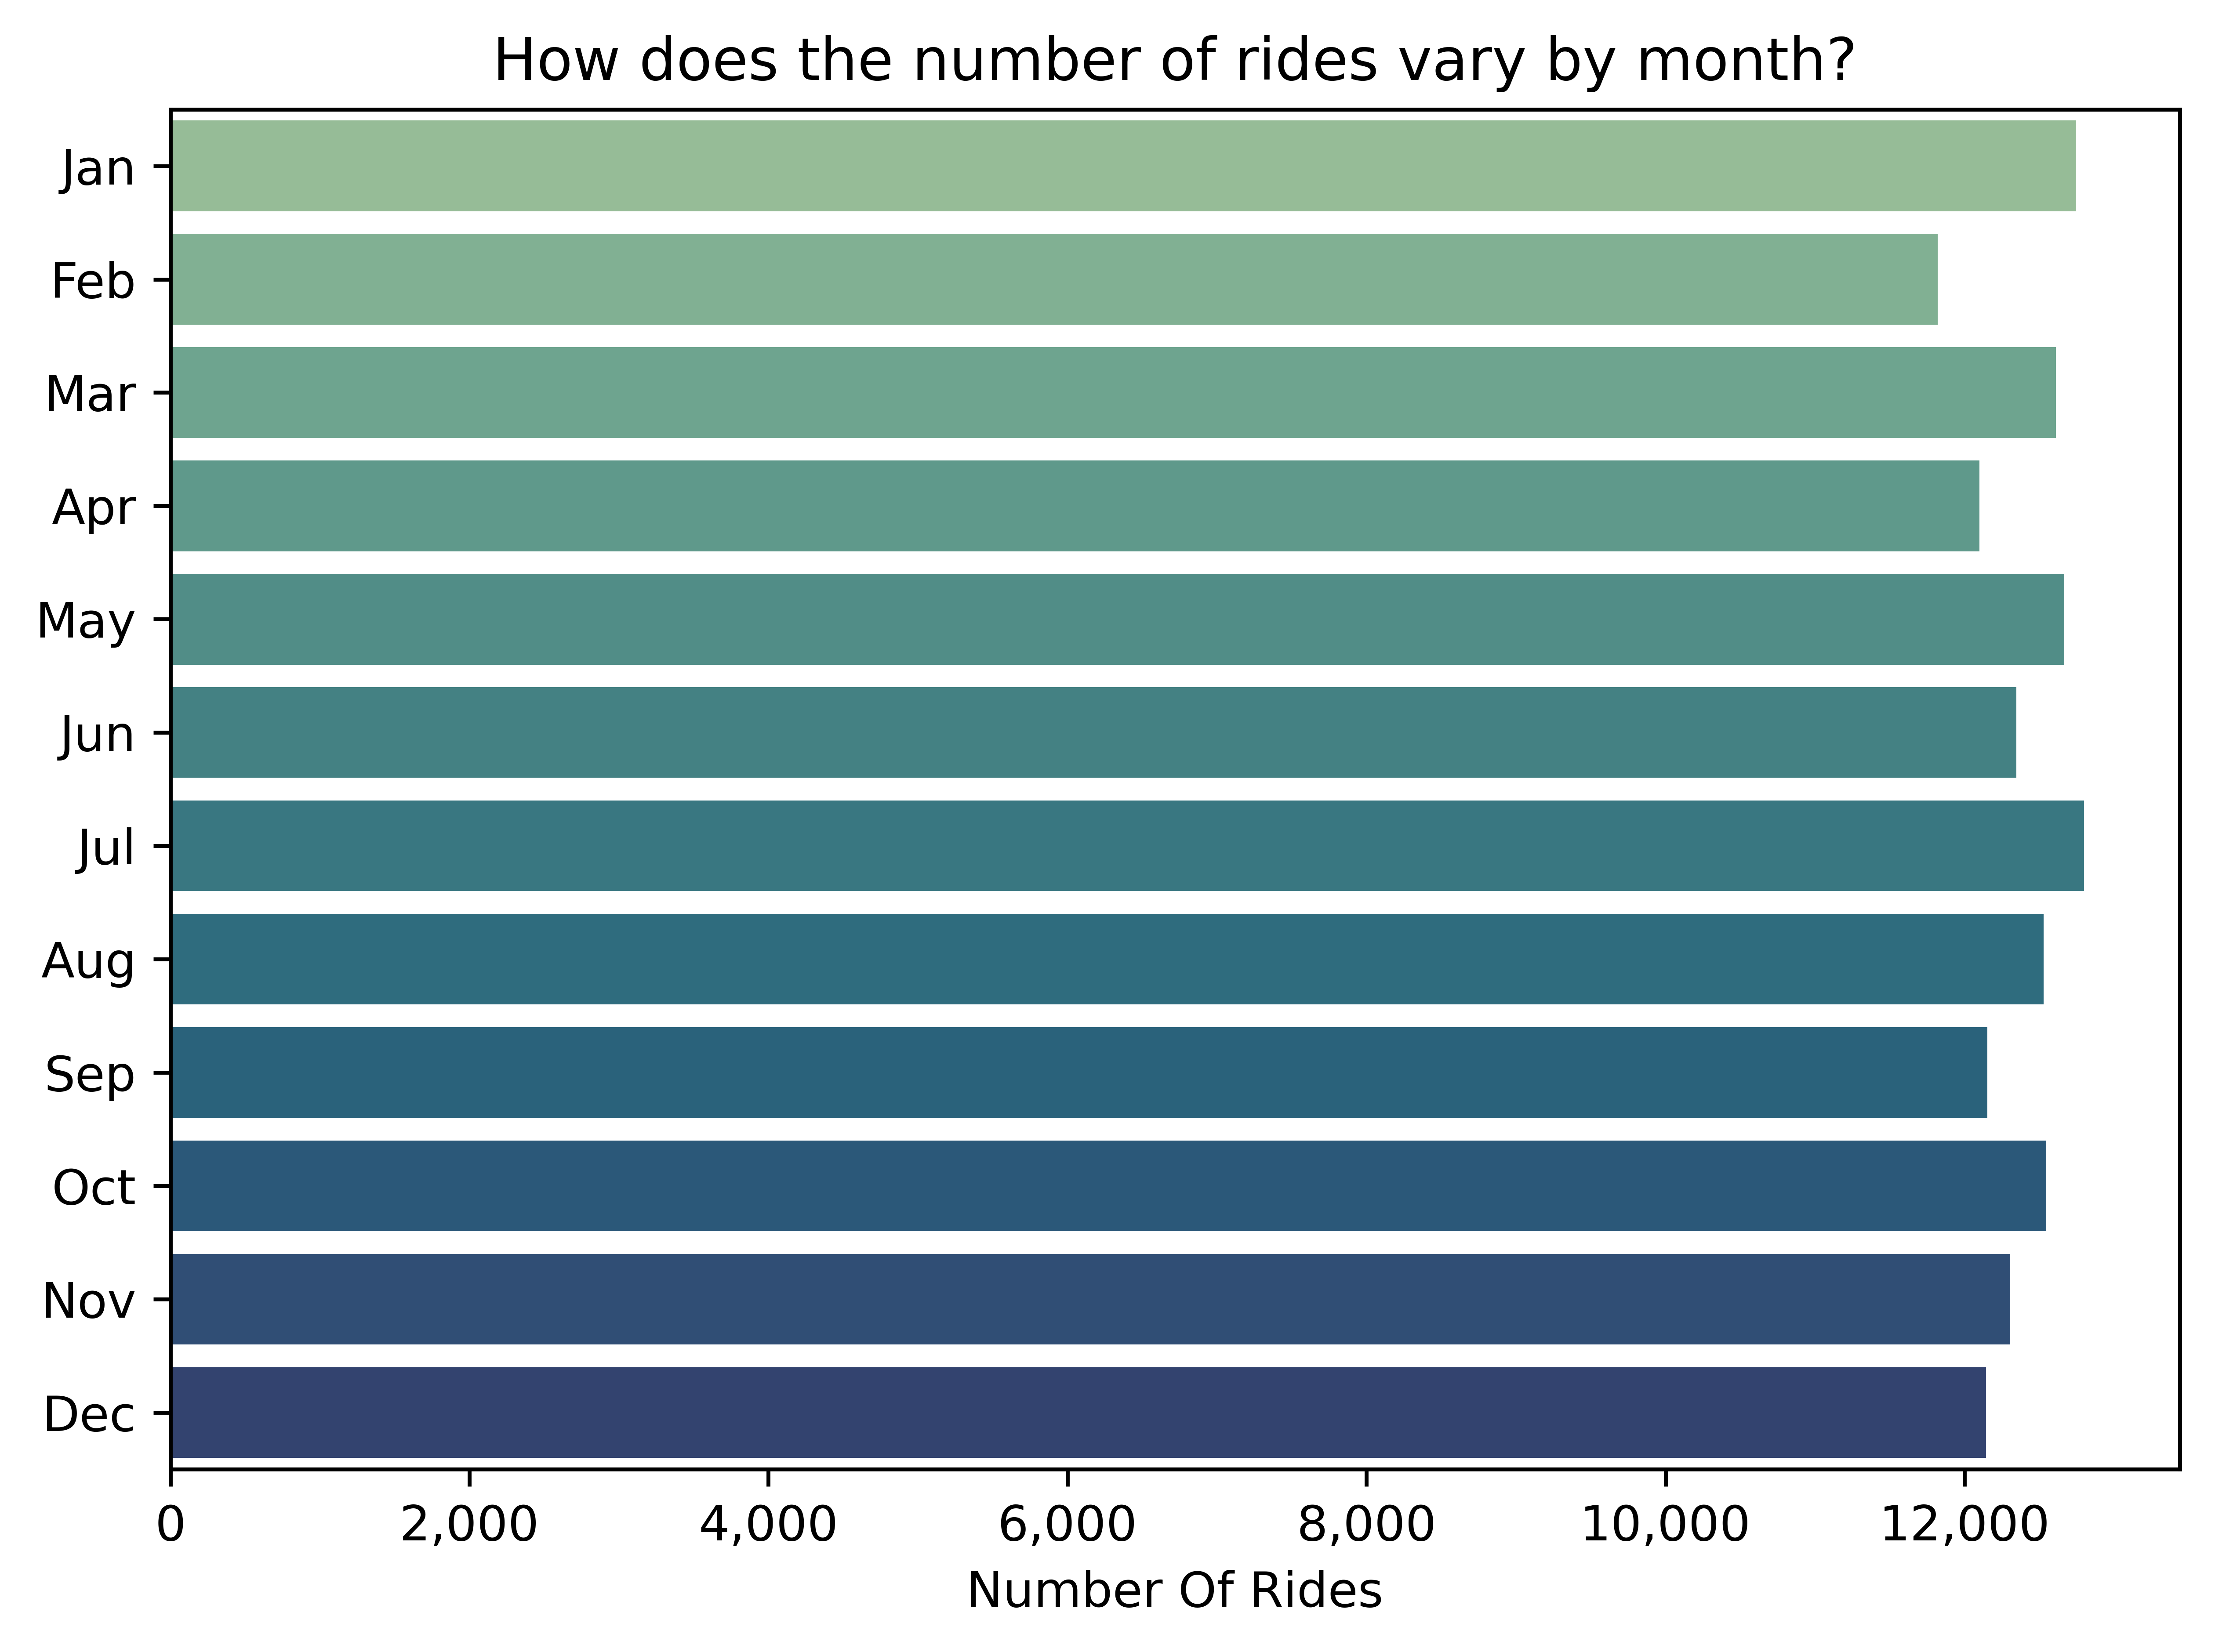

In [87]:
#Q1. How does ride volume vary month to month? Are there seasonal peaks?
csv_plot = csv.copy()
csv_plot['Month_no'] = csv_plot['Date'].dt.month
csv_plot.drop_duplicates(subset=['Booking ID'], inplace=True)
csv_plot['Month'] = csv_plot['Month_no'].apply(lambda x: pd.to_datetime(x, format='%m')).dt.strftime("%b")
csv_plot = csv_plot.groupby(['Month', 'Month_no'])['Booking ID'].count().reset_index()
csv_plot.rename(columns={'Booking ID': 'Count'}, inplace=True)
csv_plot.sort_values(by='Month_no', inplace=True)
csv_plot.drop('Month_no', axis=1, inplace=True)
csv_plot
sns.barplot(data=csv_plot, x='Count', y='Month', hue='Month', palette='crest')
plt.xlabel('Number Of Rides')
plt.ylabel('')
plt.title('How does the number of rides vary by month?')
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.gca().figure.set_dpi(800)
plt.tight_layout()
plt.show()

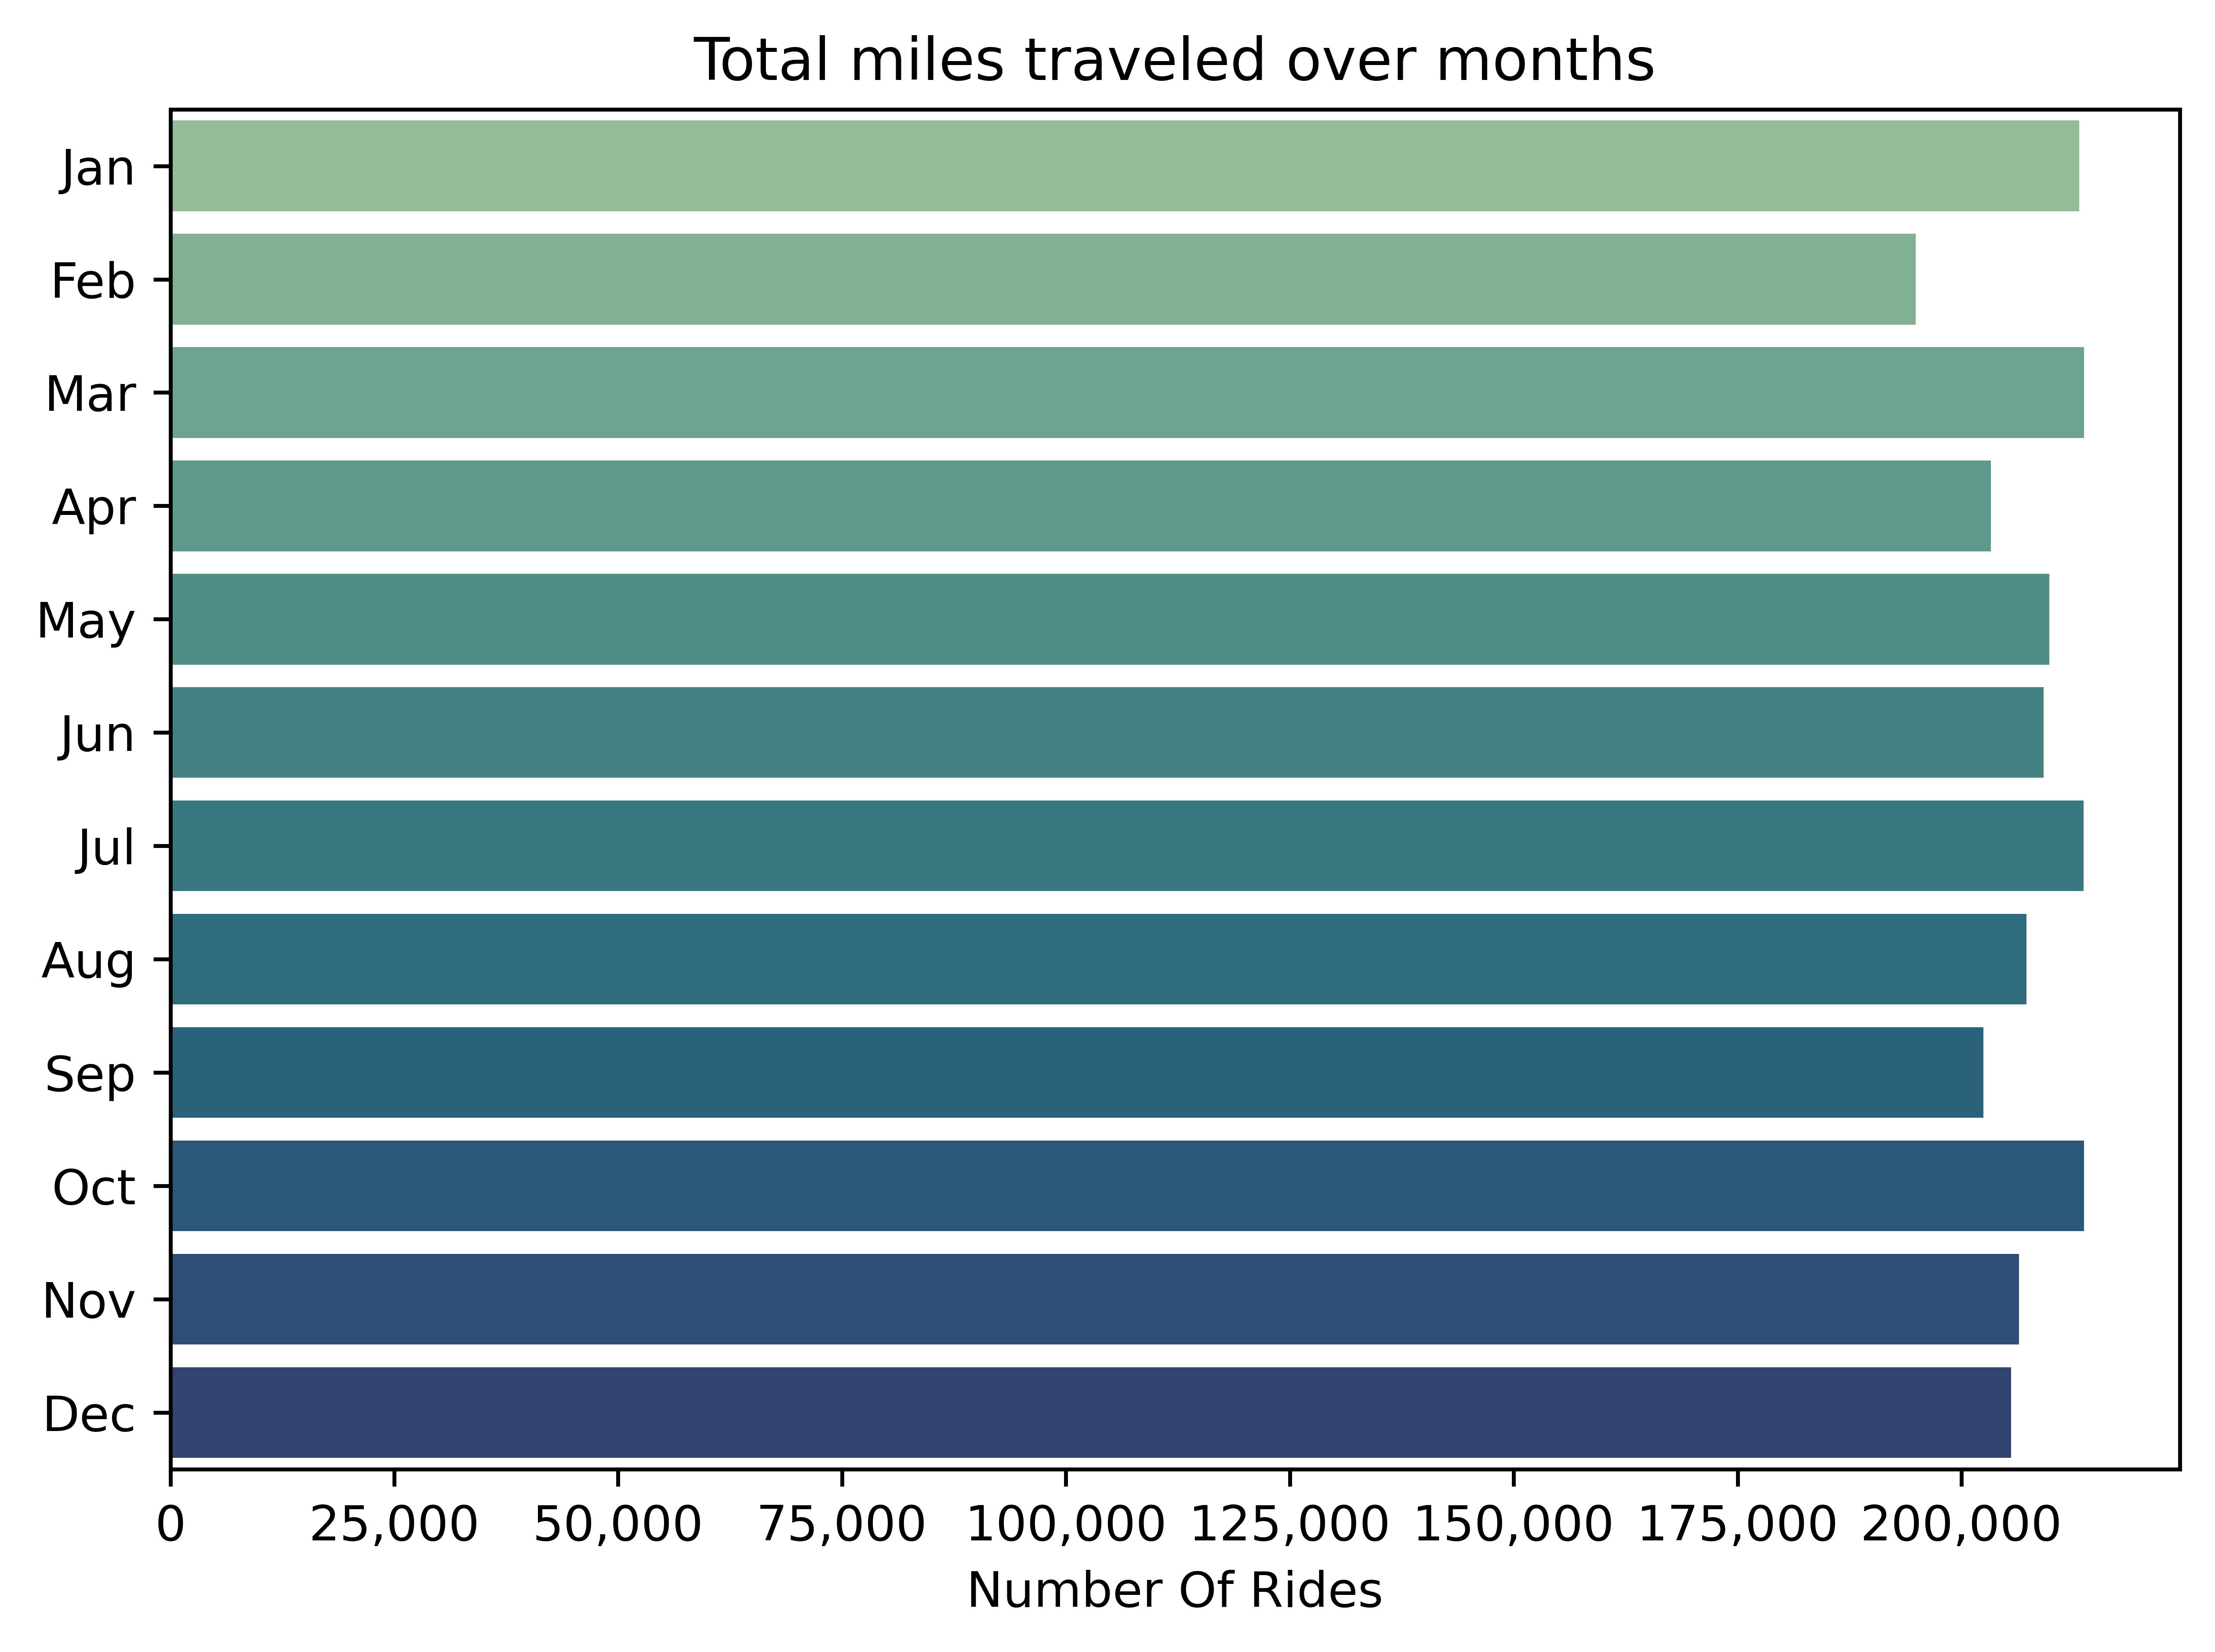

In [88]:
# How does total miles traveled vary month to month?
csv_plot = csv.copy()
csv_plot['Month_no'] = csv_plot['Date'].dt.month
csv_plot.drop_duplicates(subset=['Booking ID'], inplace=True)
csv_plot['Month'] = csv_plot['Month_no'].apply(lambda x: pd.to_datetime(x, format='%m')).dt.strftime("%b")
csv_plot = csv_plot.groupby(['Month', 'Month_no'])['Ride Distance'].sum().reset_index()
csv_plot.rename(columns={'Ride Distance': 'Total Distance'}, inplace=True)
csv_plot.sort_values(by='Month_no', inplace=True)
csv_plot.drop('Month_no', axis=1, inplace=True)
csv_plot
sns.barplot(data=csv_plot, x='Total Distance', y='Month', hue='Month', palette='crest')
plt.xlabel('Number Of Rides')
plt.ylabel('')
plt.title('Total miles traveled over months')
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.gca().figure.set_dpi(800)
plt.tight_layout()
plt.show()

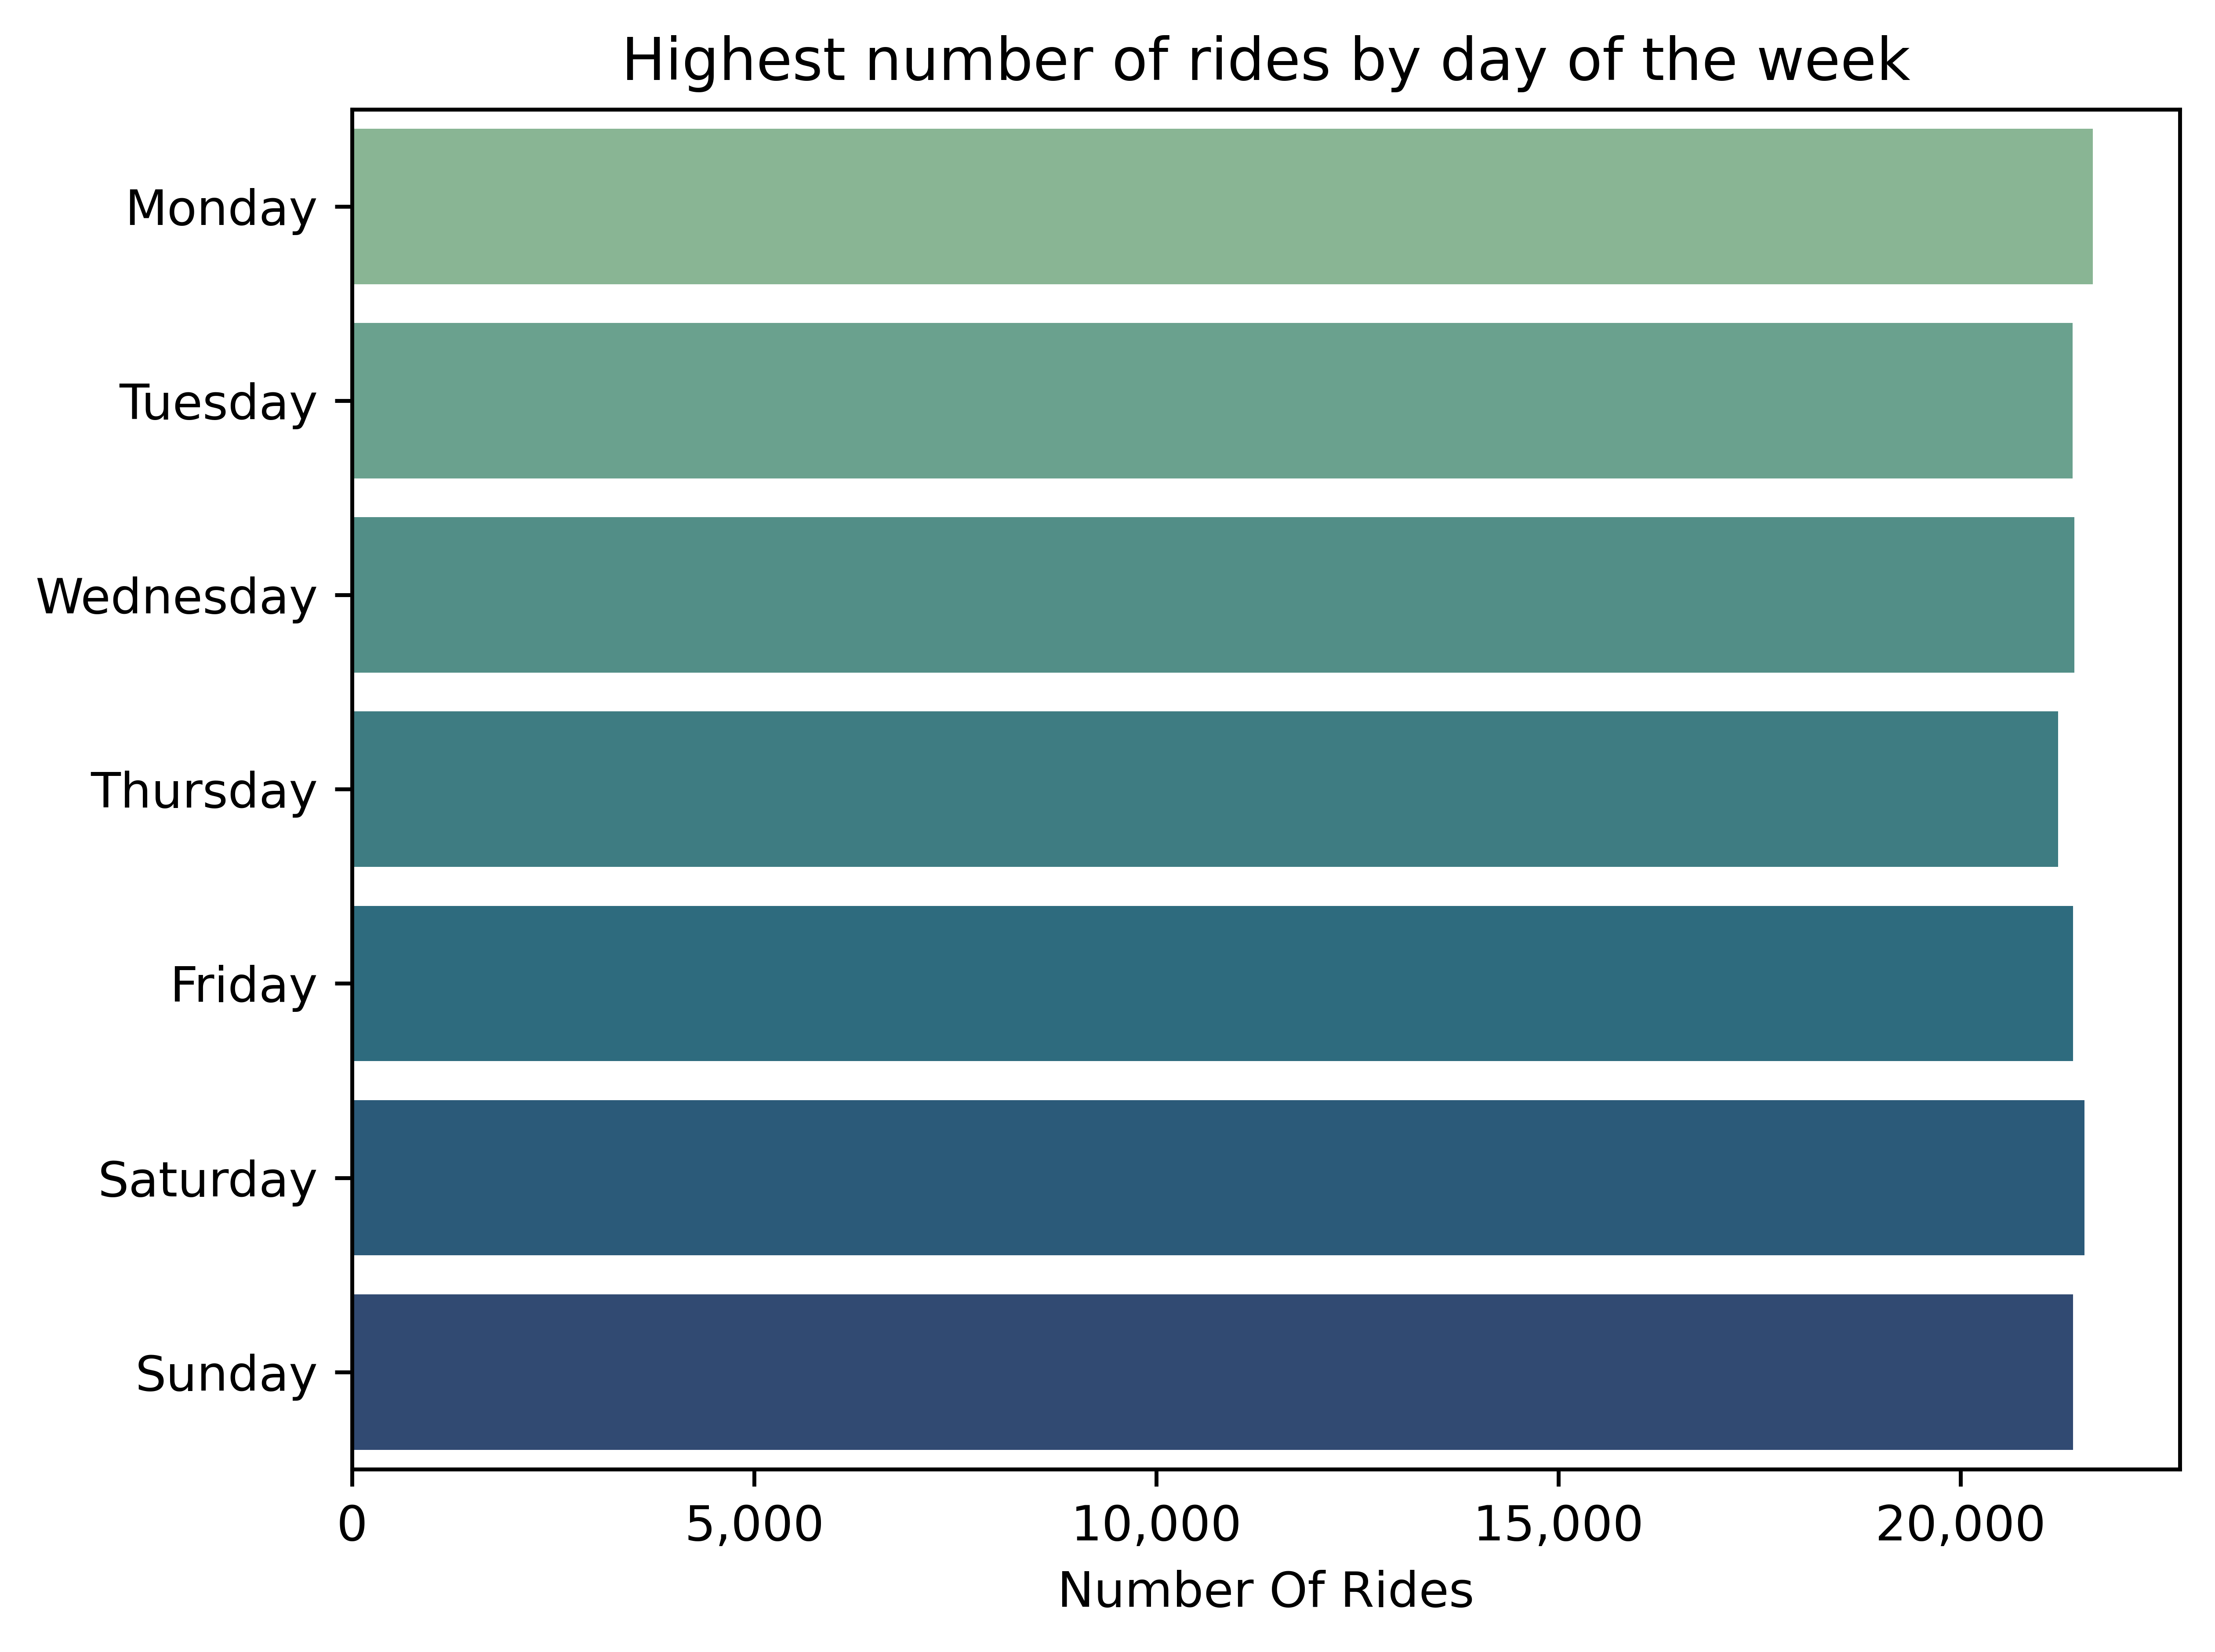

In [89]:
# Which times of day see the highest number of rides?
csv_plot = csv.copy()
csv_plot['Day_name'] = csv_plot['Date'].dt.day_name()
csv_plot['Day_num'] = csv_plot['Date'].dt.day_of_week
csv_plot = csv_plot.groupby(['Day_name', "Day_num"])["Booking ID"].count().reset_index()
sns.barplot(data=csv_plot.sort_values("Day_num"), x='Booking ID', y='Day_name', hue='Day_name', palette='crest')
plt.xlabel('Number Of Rides')
plt.ylabel('')
plt.title('Highest number of rides by day of the week')
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.gca().figure.set_dpi(800)
plt.tight_layout()
plt.show()

/var/folders/s_/ggnpv55n1fg1ylmddwvfk_bc0000gn/T/ipykernel_1030/1684828772.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  csv_plot = csv_plot.groupby(['Distance Category', 'Time Category'])['Booking ID'].count().reset_index()


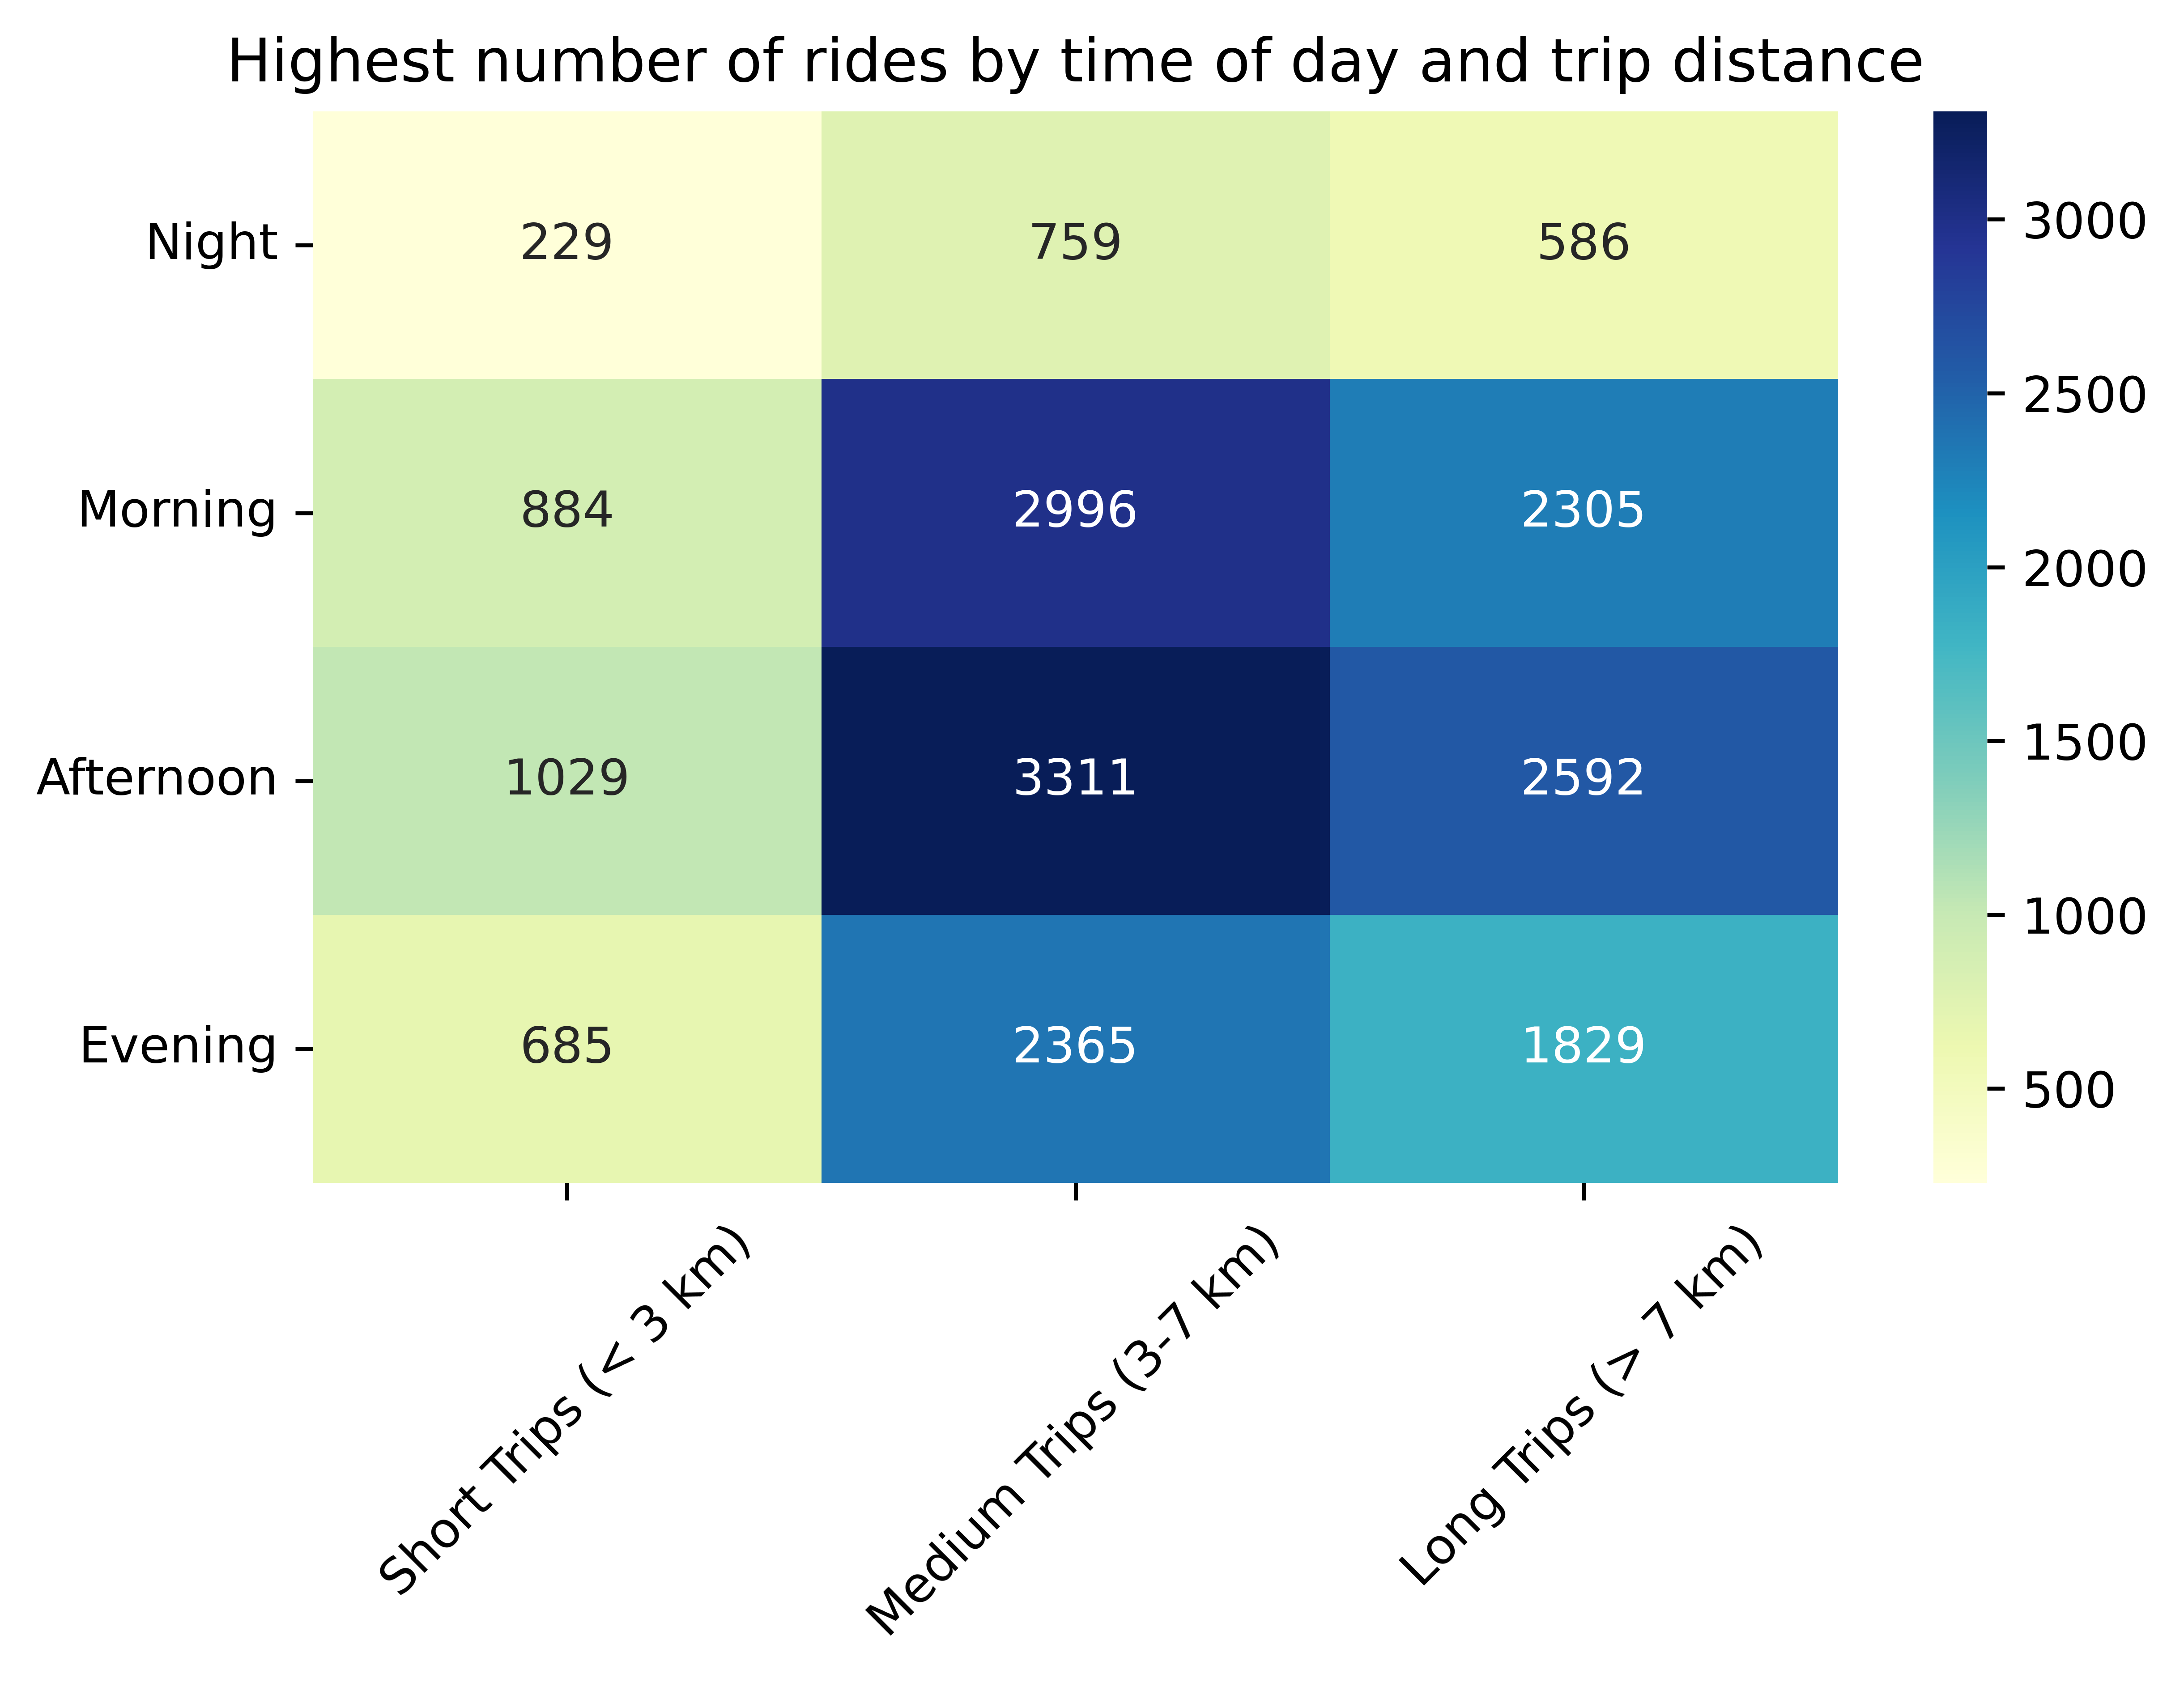

In [109]:
# Do longer trips occur more often during specific times of day (morning commute, afternoon, evening)?
csv_plot = csv.copy()
csv_plot['Time'] = pd.to_datetime(csv_plot['Time'], format='%H:%M:%S')
csv_plot['Distance Category'] = pd.cut(csv_plot['Ride Distance'], bins=[0, 3, 7, 10], labels=['Short Trips (< 3 km)', 'Medium Trips (3-7 km)', 'Long Trips (> 7 km)'])
csv_plot['Hour'] = csv_plot['Time'].dt.hour
csv_plot['Time Category'] = pd.cut(csv_plot['Hour'], bins=[0, 6, 12, 18, 24], labels=['Night', 'Morning', 'Afternoon', 'Evening'])
csv_plot = csv_plot.groupby(['Distance Category', 'Time Category'])['Booking ID'].count().reset_index()
csv_pivot = csv_plot.pivot(index='Time Category', columns='Distance Category', values='Booking ID')
csv_pivot
sns.heatmap(csv_pivot, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Highest number of rides by time of day and trip distance')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.xlabel('')
plt.ylabel('')
plt.gca().figure.set_dpi(800)
plt.tight_layout()
plt.show()

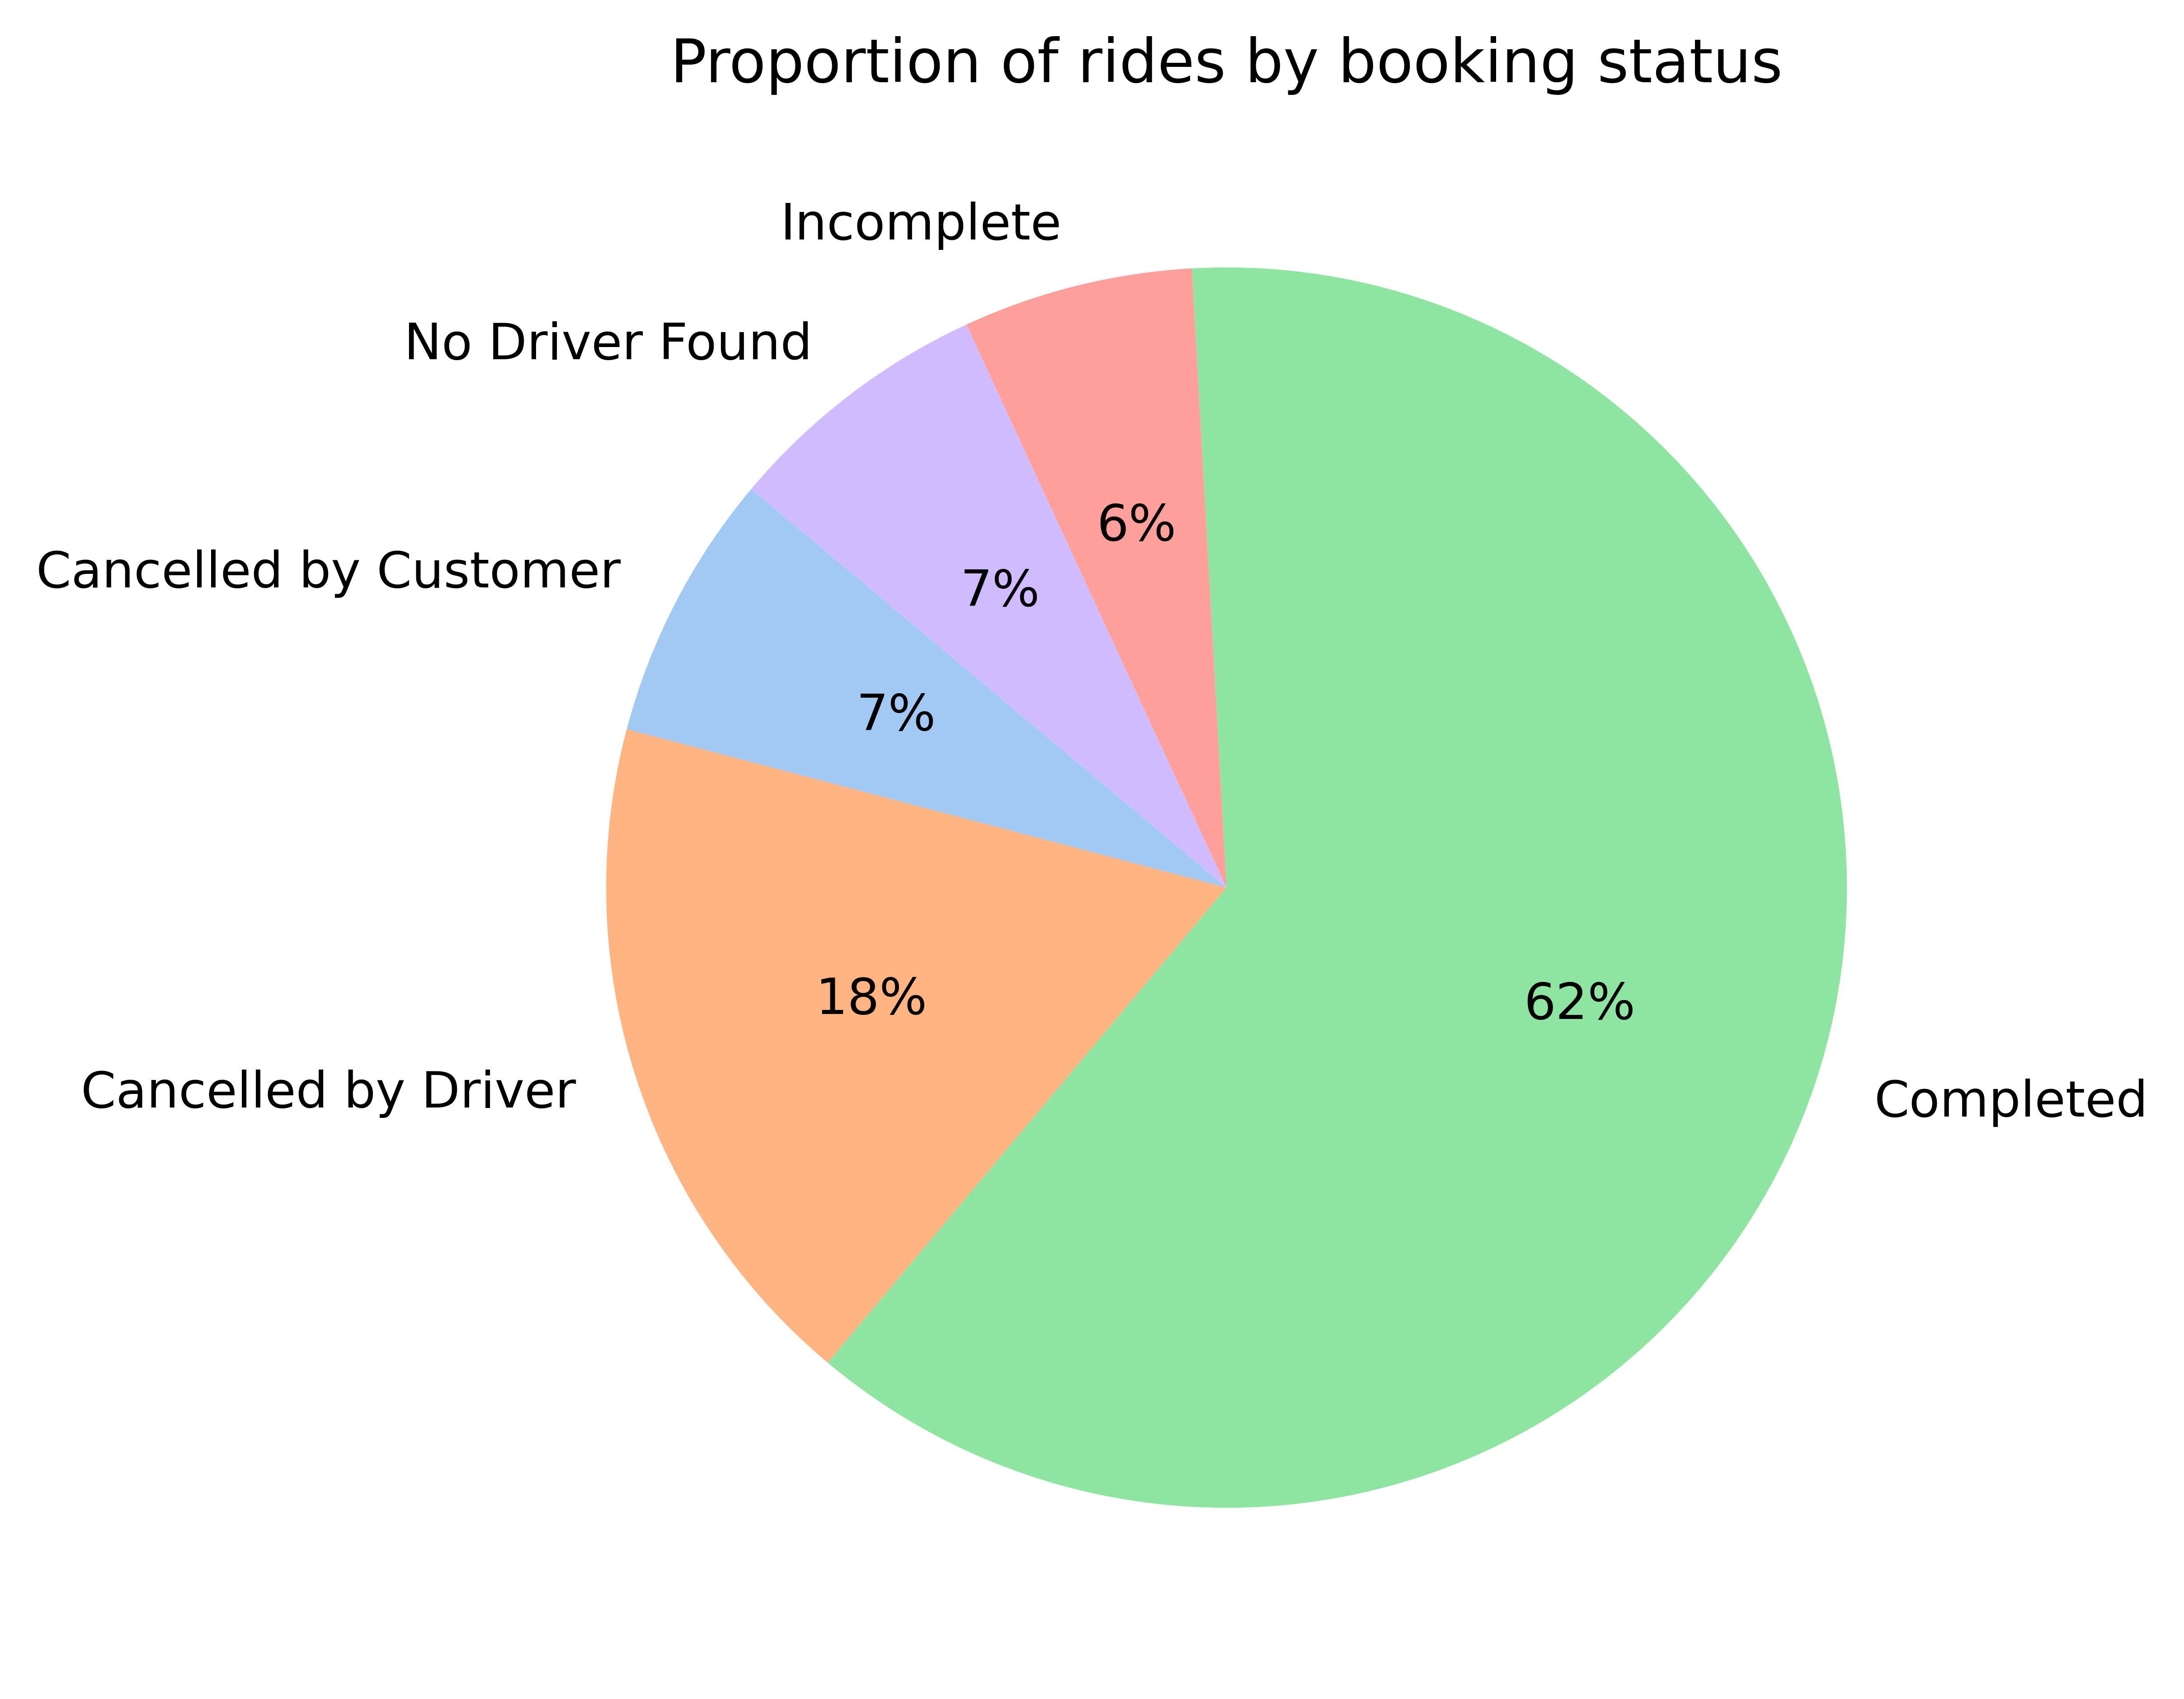

In [120]:
#Q2. What proportion of rides are completed, cancelled, or incomplete?
csv_plot = csv.copy()
csv_grouped = csv_plot.groupby(['Booking Status'])['Booking ID'].count().reset_index()
csv_grouped.plot(kind='pie', y='Booking ID', labels=csv_grouped['Booking Status'], autopct='%1.0f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Proportion of rides by booking status')
plt.legend().remove()
plt.xlabel('')
plt.ylabel('')
plt.gca().figure.set_dpi(800)
plt.tight_layout()
plt.show()

/var/folders/s_/ggnpv55n1fg1ylmddwvfk_bc0000gn/T/ipykernel_1030/2144367072.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


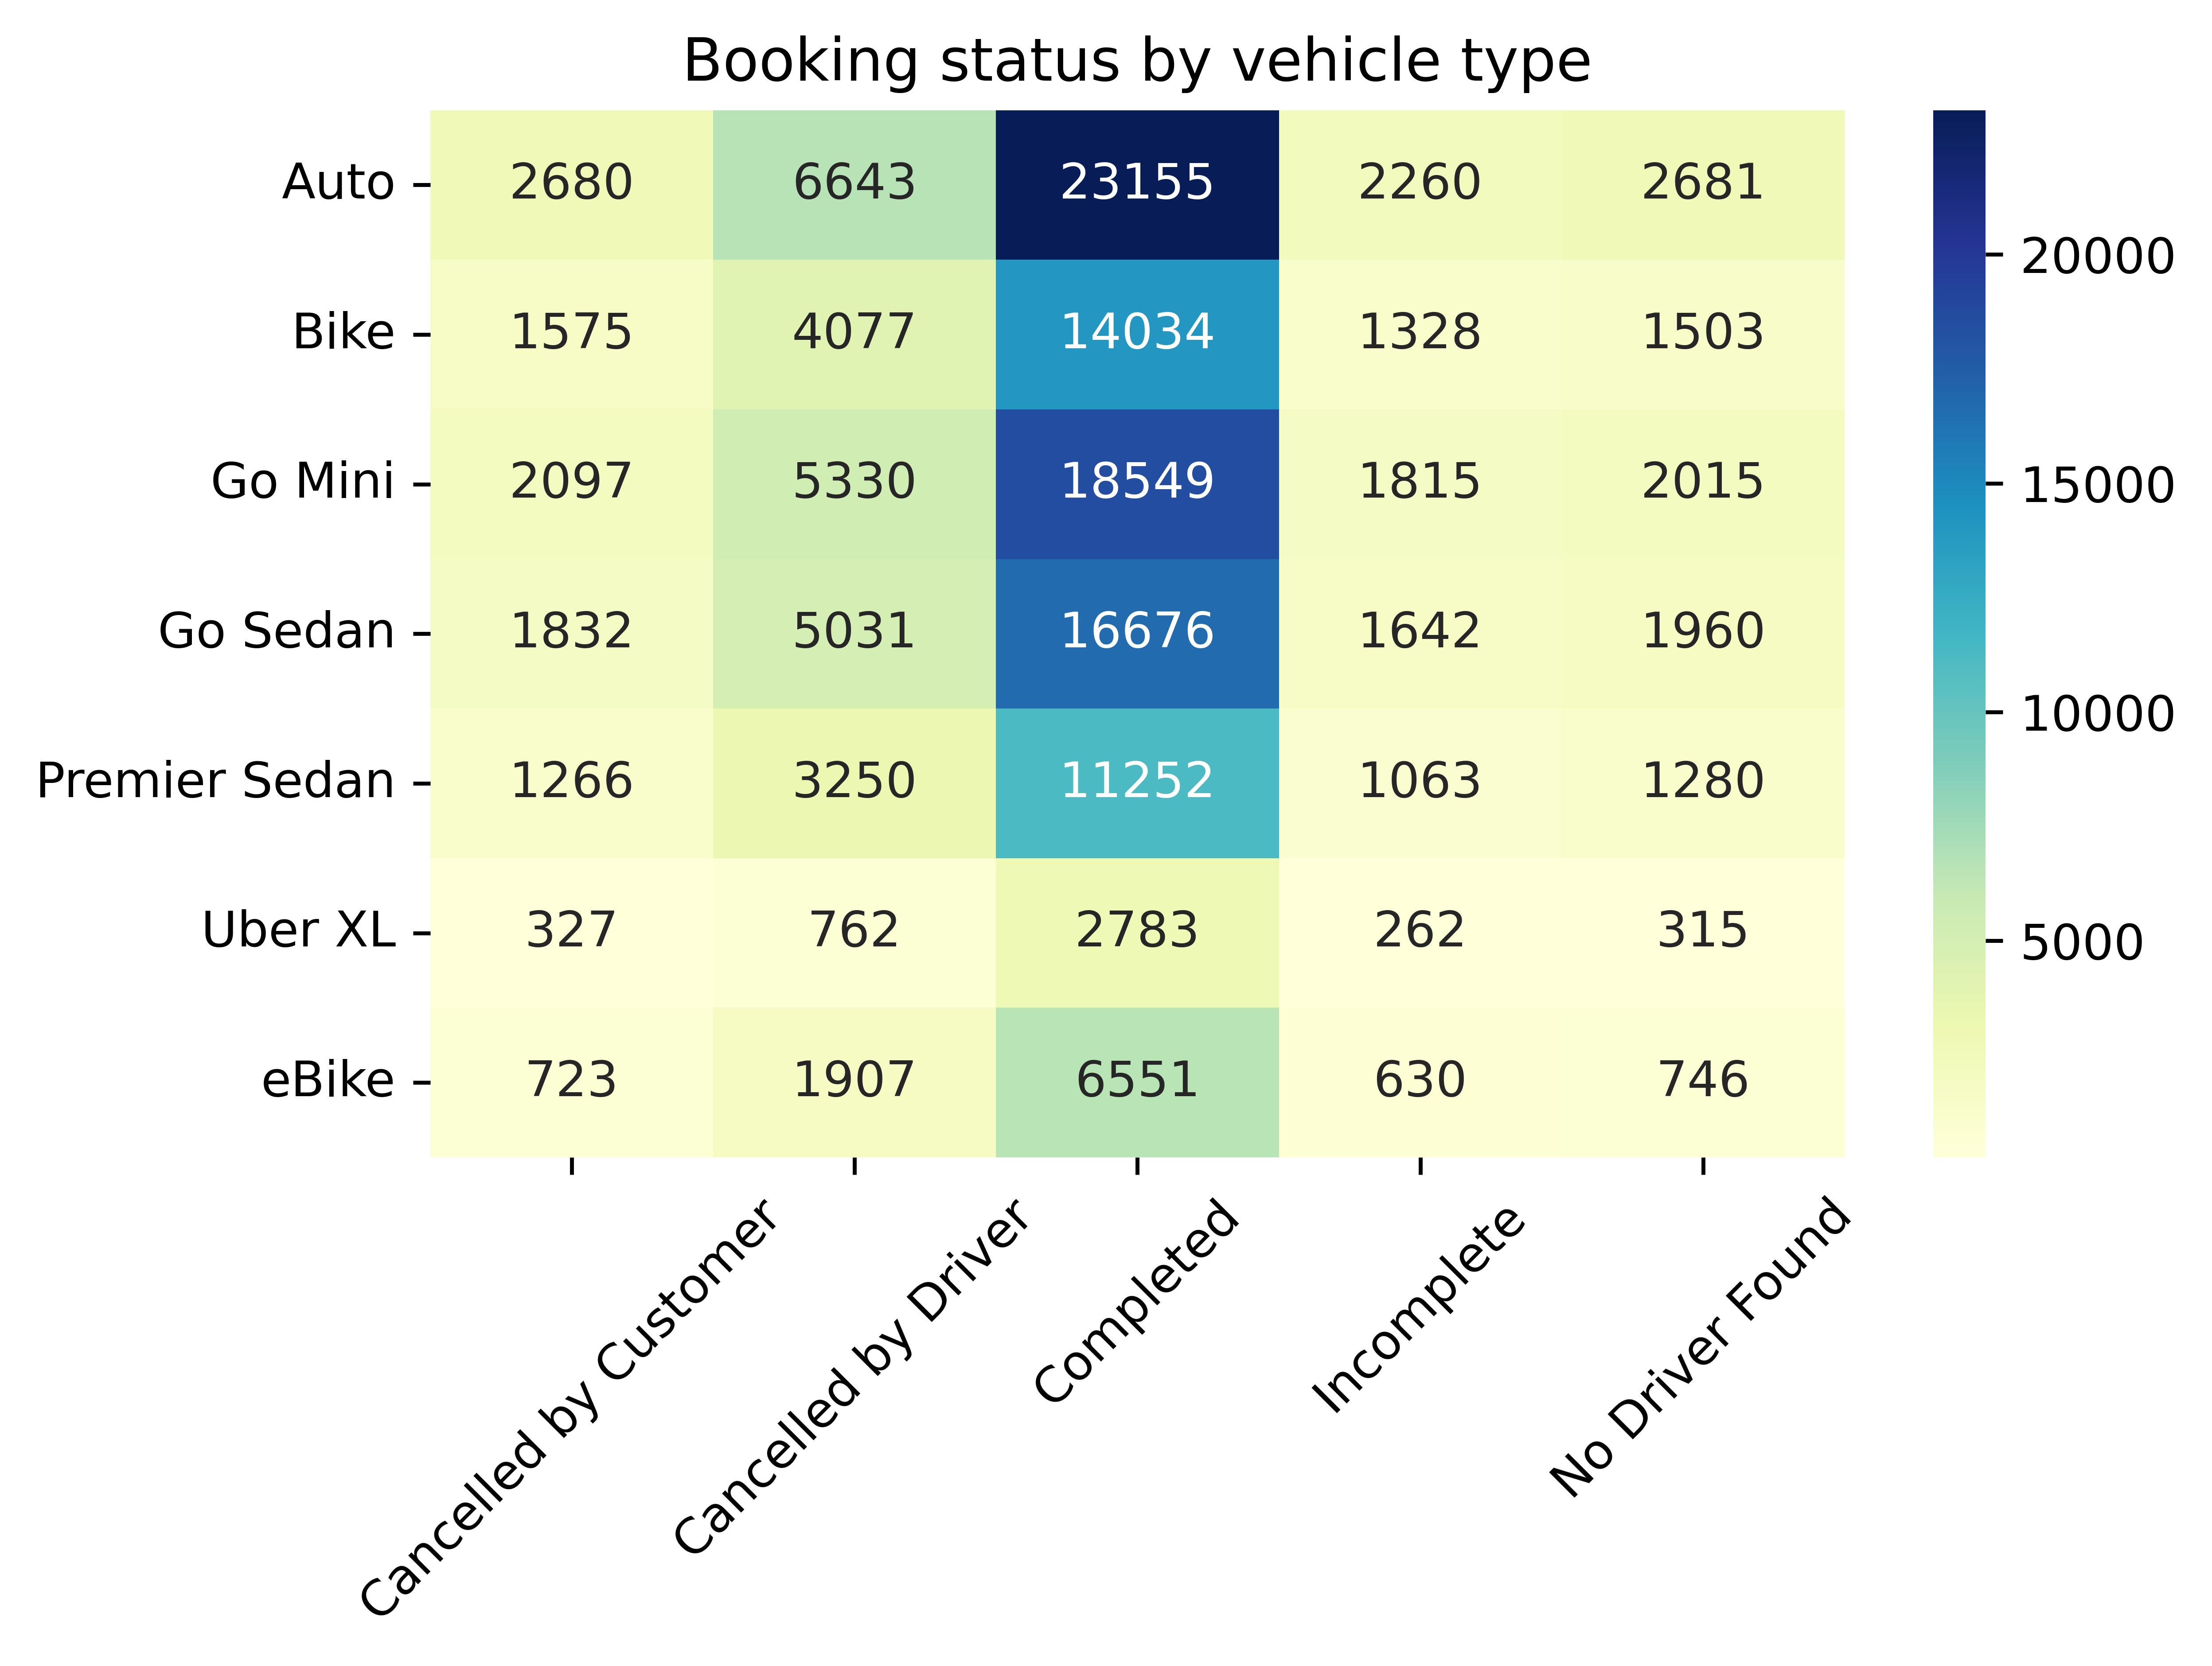

In [125]:
# How does booking status vary across different vehicle types?
csv_plot = csv.copy()
csv_grouped = csv_plot.groupby(['Vehicle Type', 'Booking Status'])['Booking ID'].count().reset_index()
csv_pivot = csv_grouped.pivot(index='Vehicle Type', columns='Booking Status', values='Booking ID')
sns.heatmap(csv_pivot, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Booking status by vehicle type')
plt.xticks(rotation=45)
plt.legend().remove()
plt.xlabel('')
plt.ylabel('')
plt.gca().figure.set_dpi(800)
plt.tight_layout()
plt.show()

/var/folders/s_/ggnpv55n1fg1ylmddwvfk_bc0000gn/T/ipykernel_1030/1732371018.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  csv_plot = csv_plot.groupby(['Vehicle Type', 'Time Category'])['Booking ID'].count().reset_index()
/var/folders/s_/ggnpv55n1fg1ylmddwvfk_bc0000gn/T/ipykernel_1030/1732371018.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


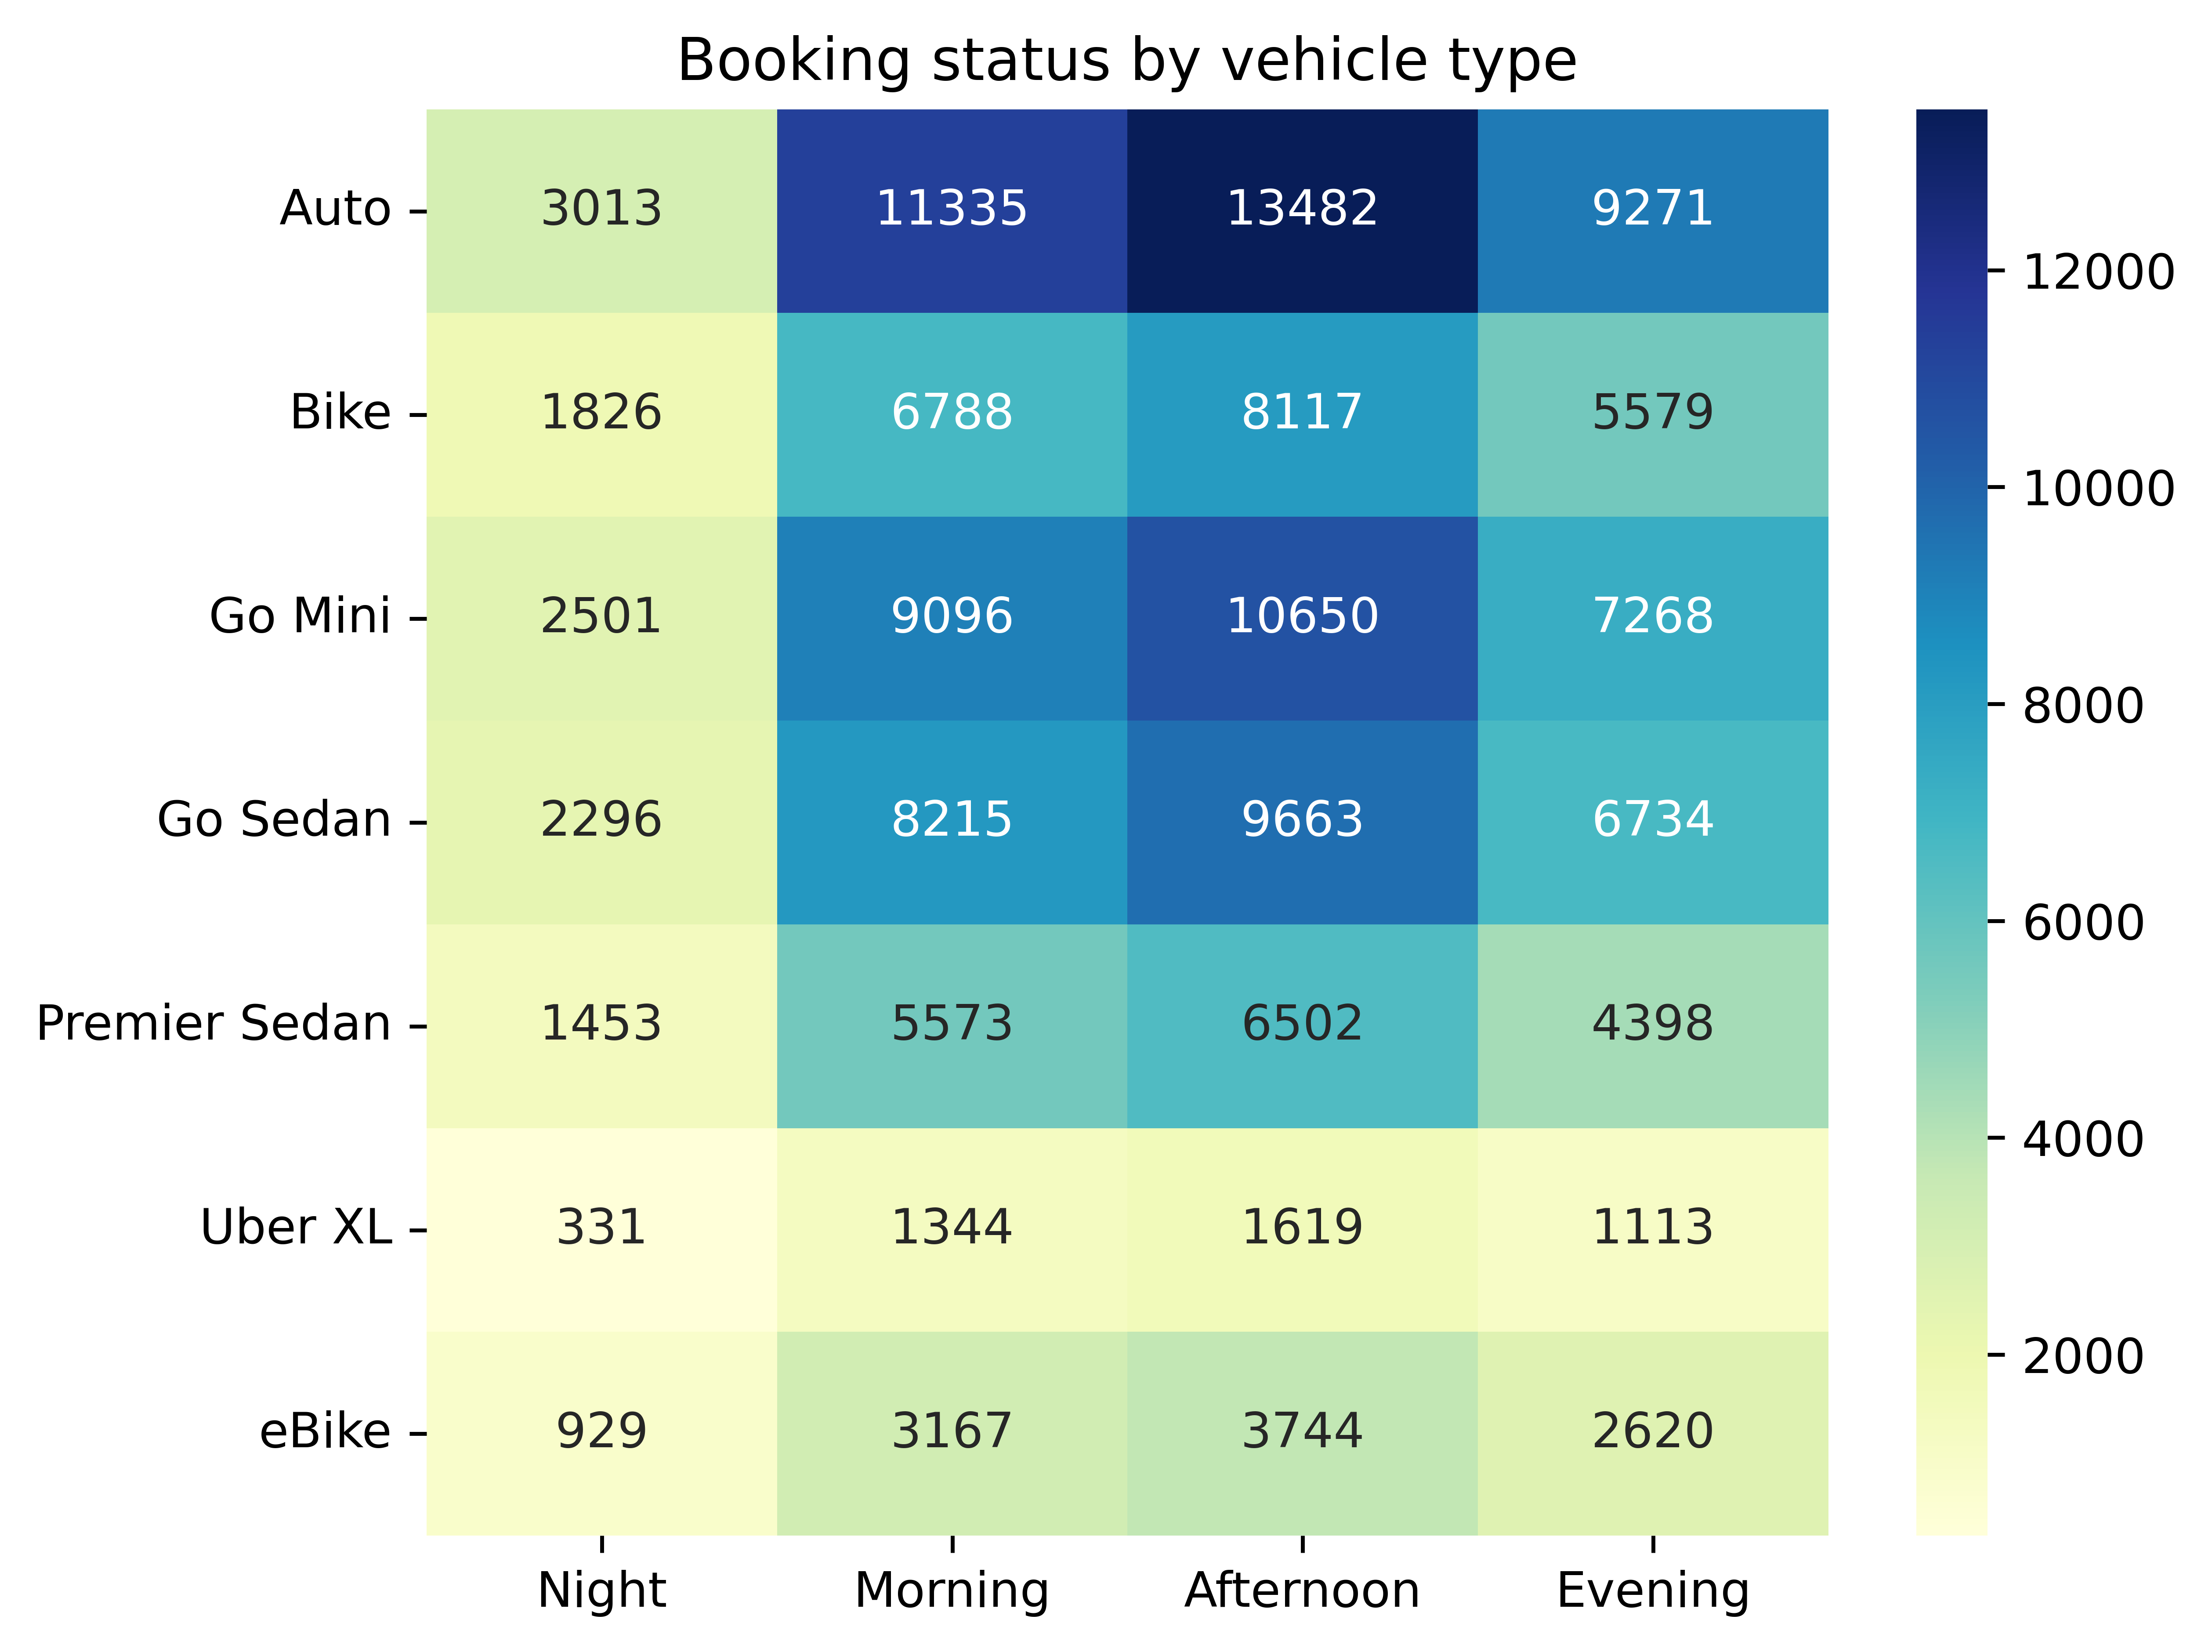

In [129]:
# Are certain vehicle types used more frequently at specific times of day?
csv_plot = csv.copy()
csv_plot['Time'] = pd.to_datetime(csv_plot['Time'], format='%H:%M:%S')
csv_plot['Hour'] = csv_plot['Time'].dt.hour
csv_plot['Time Category'] = pd.cut(csv_plot['Hour'], bins=[0, 6, 12, 18, 24], labels=['Night', 'Morning', 'Afternoon', 'Evening'])
csv_plot = csv_plot.groupby(['Vehicle Type', 'Time Category'])['Booking ID'].count().reset_index()
csv_pivot = csv_plot.pivot(index='Vehicle Type', columns='Time Category', values='Booking ID')
sns.heatmap(data=csv_pivot, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Vehicle type usage by time of day')
plt.title('Booking status by vehicle type')
plt.legend().remove()
plt.xlabel('')
plt.ylabel('')
plt.gca().figure.set_dpi(800)
plt.tight_layout()
plt.show()

/var/folders/s_/ggnpv55n1fg1ylmddwvfk_bc0000gn/T/ipykernel_1030/2877035039.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=csv_plot, y='Vehicle Type', x='Ride Distance', palette='crest')
/var/folders/s_/ggnpv55n1fg1ylmddwvfk_bc0000gn/T/ipykernel_1030/2877035039.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


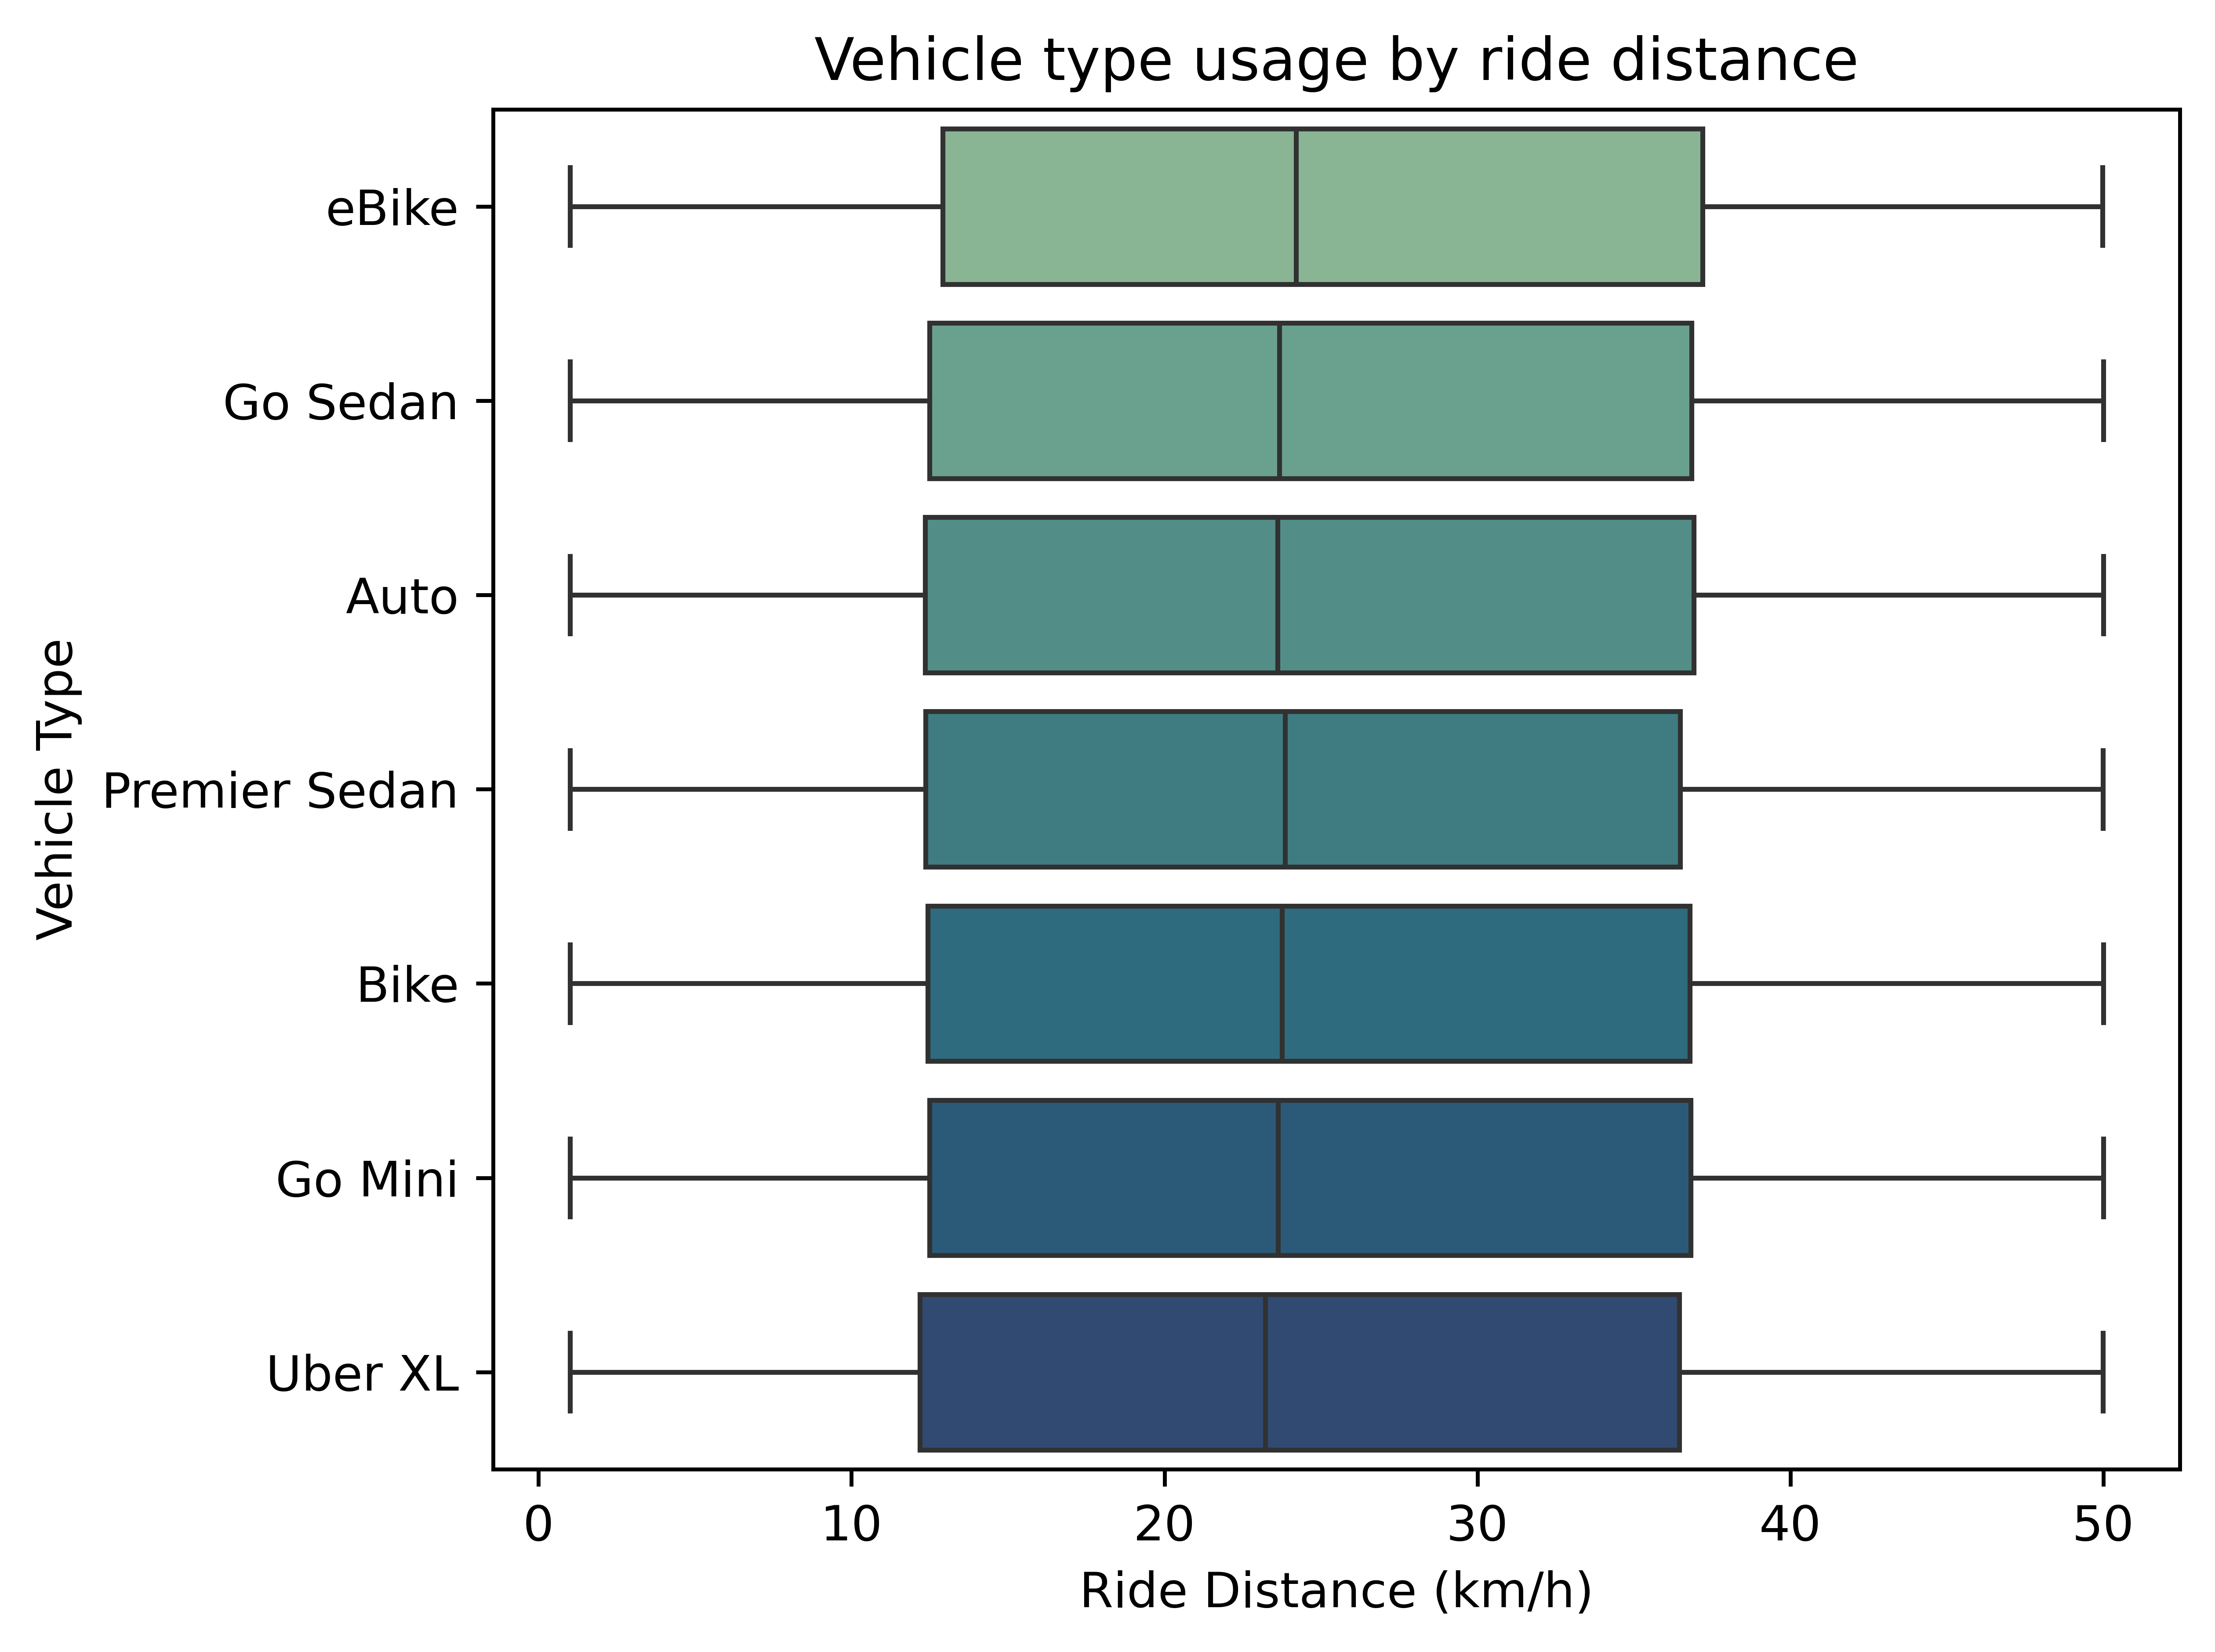

In [133]:
# Do certain vehicle types tend to have longer ride distances?
csv_plot = csv.copy()
sns.boxplot(data=csv_plot, y='Vehicle Type', x='Ride Distance', palette='crest')
plt.title('Vehicle type usage by ride distance')
plt.legend().remove()
plt.xlabel('Ride Distance (km/h)')
plt.ylabel('Vehicle Type')
plt.gca().figure.set_dpi(800)
plt.tight_layout()
plt.show()

/var/folders/s_/ggnpv55n1fg1ylmddwvfk_bc0000gn/T/ipykernel_1030/1053066058.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=csv_pivot.reset_index(), y='Vehicle Type', x='Cancelled by Customer', palette='crest')
/var/folders/s_/ggnpv55n1fg1ylmddwvfk_bc0000gn/T/ipykernel_1030/1053066058.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=csv_pivot.reset_index(), y='Vehicle Type', x='Cancelled by Driver', palette='crest')
/var/folders/s_/ggnpv55n1fg1ylmddwvfk_bc0000gn/T/ipykernel_1030/1053066058.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.leg

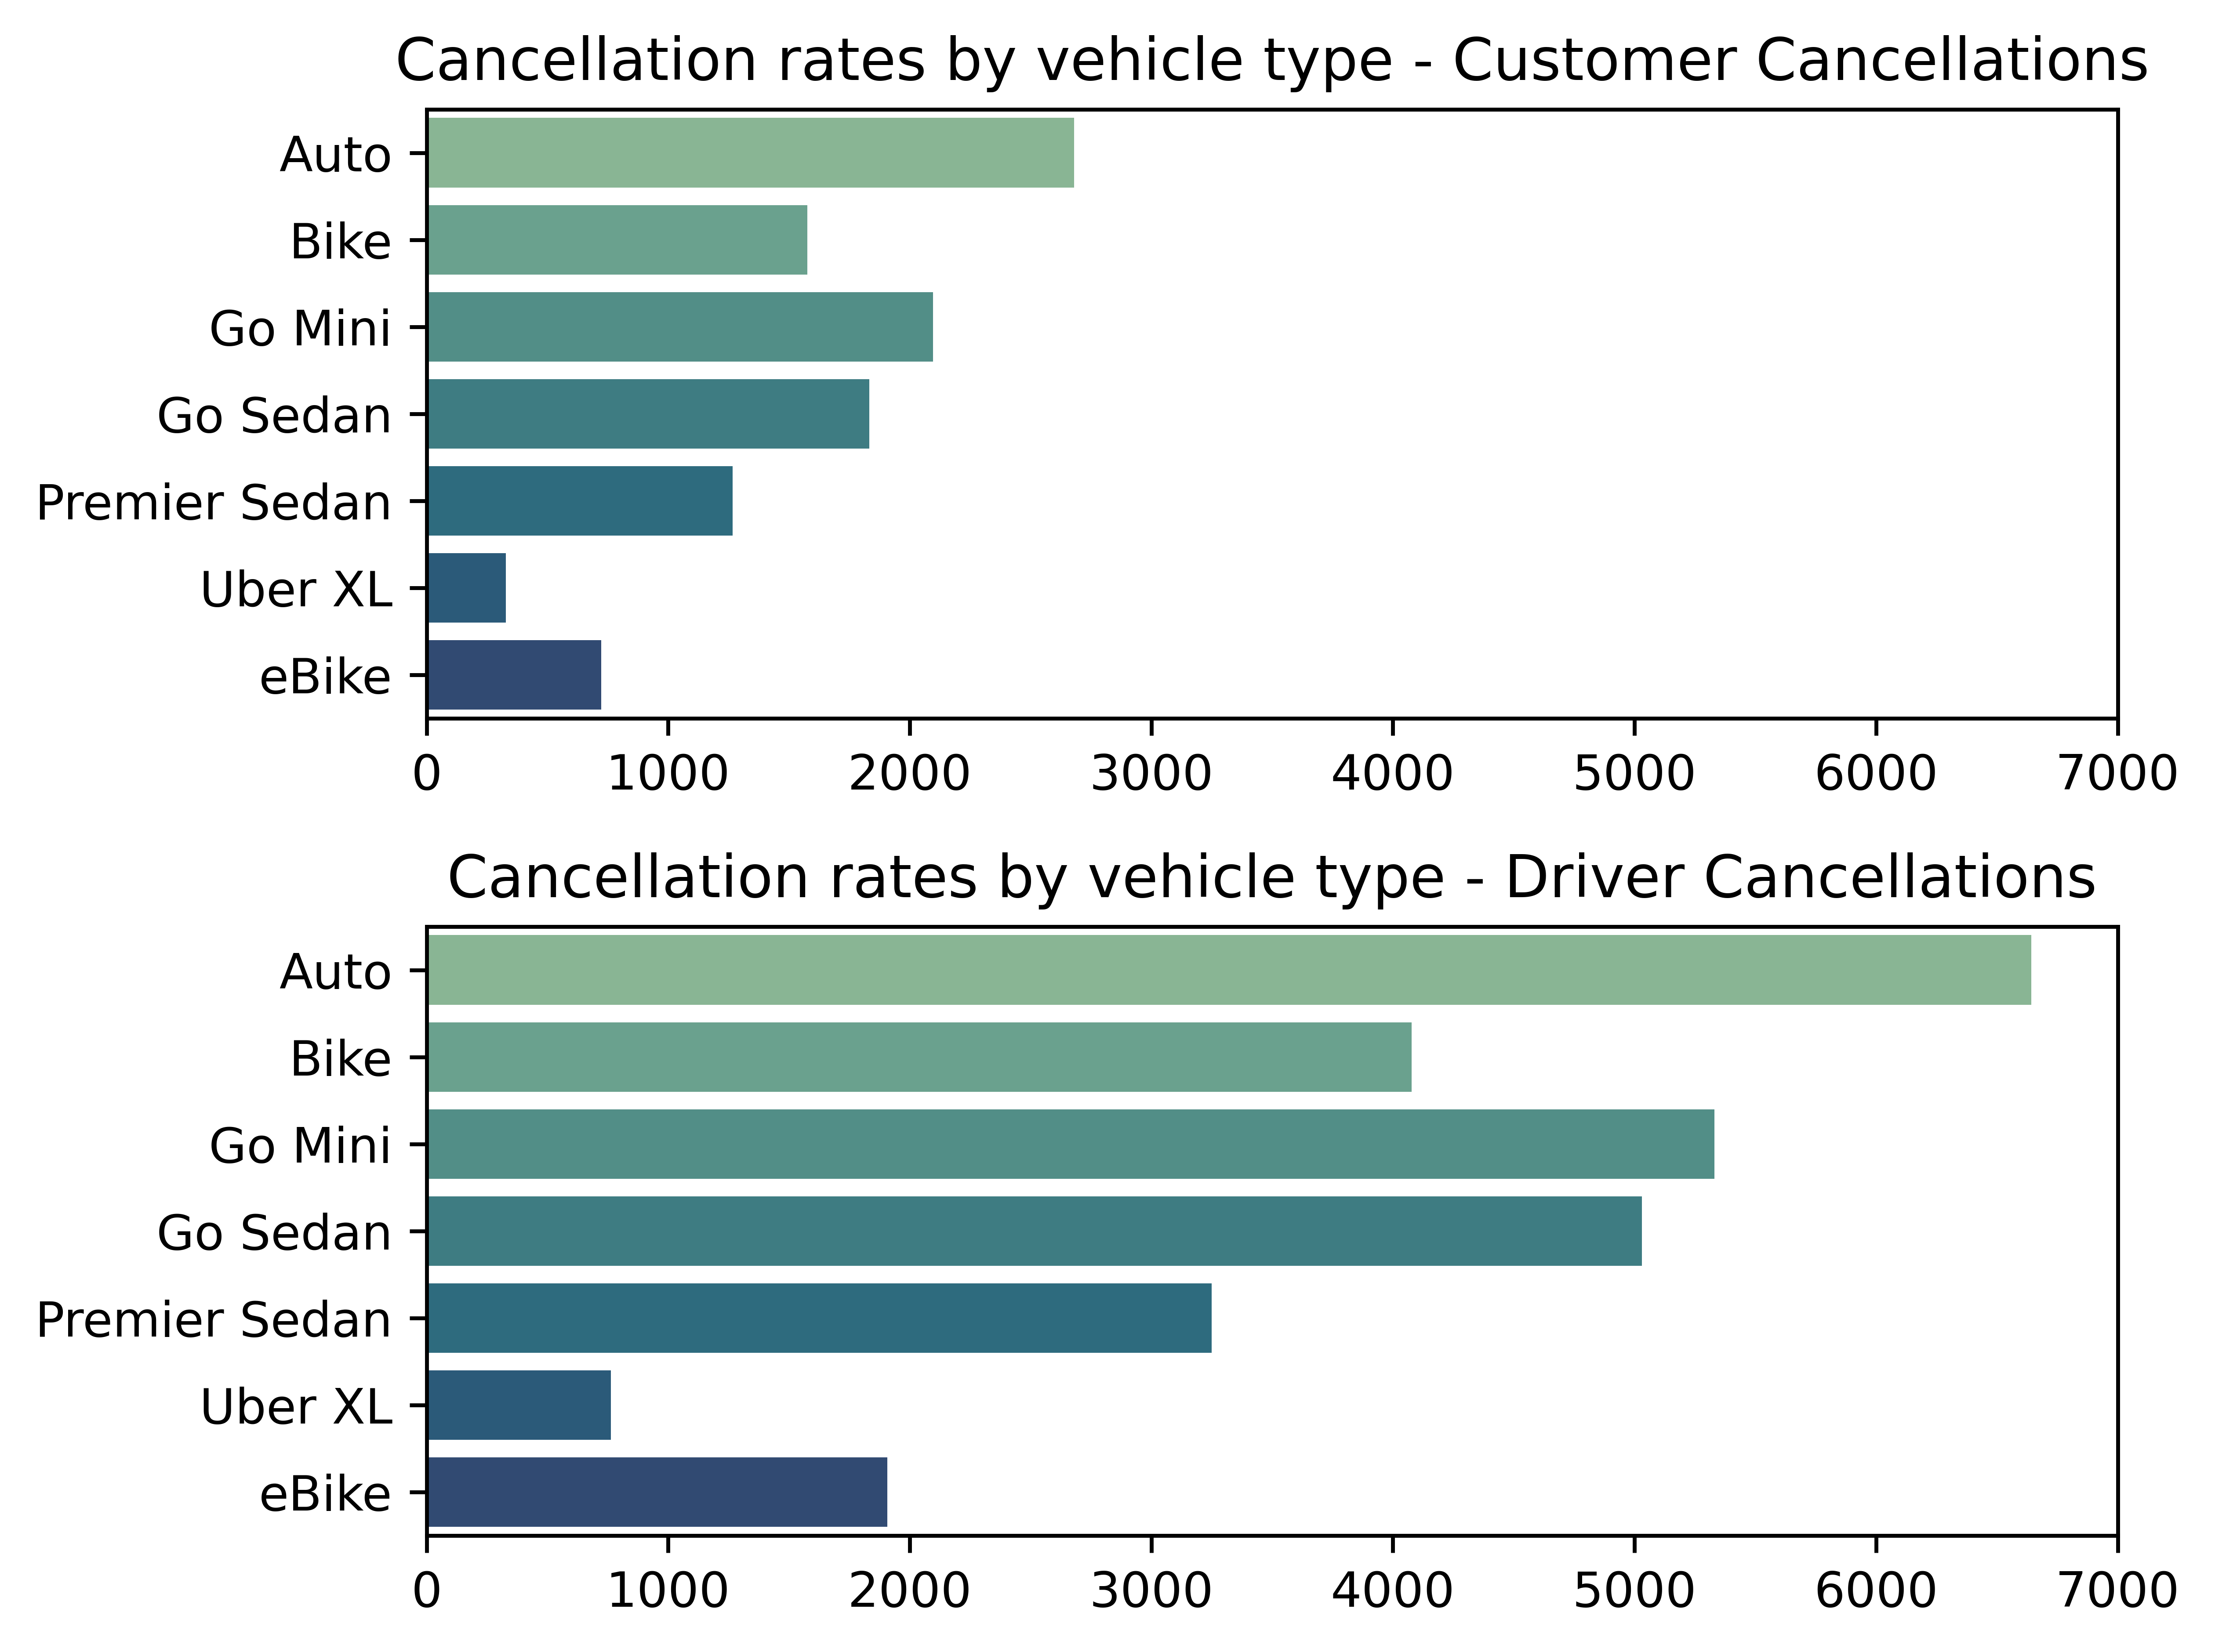

In [156]:
# How do cancellation rates differ by vehicle type?
csv_plot = csv.copy()
csv_grouped = csv_plot.groupby(['Vehicle Type', 'Booking Status'])['Booking ID'].count().reset_index()
csv_pivot = csv_grouped.pivot(index='Vehicle Type', columns='Booking Status', values='Booking ID')
csv_pivot.drop(labels=['Completed', 'Incomplete', 'No Driver Found'], axis=1, inplace=True)
csv_pivot.reset_index(inplace=True)
plt.subplot(2, 1, 1)
sns.barplot(data=csv_pivot.reset_index(), y='Vehicle Type', x='Cancelled by Customer', palette='crest')
plt.title('Cancellation rates by vehicle type - Customer Cancellations')
plt.xlabel('')
plt.ylabel('')
plt.xlim(0, 7000)
plt.gca().figure.set_dpi(800)
plt.tight_layout()
plt.subplot(2, 1, 2)
sns.barplot(data=csv_pivot.reset_index(), y='Vehicle Type', x='Cancelled by Driver', palette='crest')
plt.title('Cancellation rates by vehicle type - Driver Cancellations')
plt.legend().remove()
plt.xlabel('')
plt.ylabel('')
plt.xlim(0, 7000)
plt.gca().figure.set_dpi(800)
plt.tight_layout()
plt.show()